In [ ]:
pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.2 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=9b99dd3635a07dceb9689eda230d7374f1687e01ef22da63a37769a861470712
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


In [ ]:
#Importing Libraries
import pandas as pd #to read data
import numpy as np #to perform mathematical operartions
import re #for string formatting
import nltk #for text pre processing
import matplotlib.pyplot as plt #to plot graphs
from sentence_transformers import SentenceTransformer #for generating embeddings
import tensorflow as tf #to create DNN
import keras #to make API calls for DNN
from sklearn.model_selection import train_test_split #to split dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #to evaluate models
import torch #for tensors
import random
#to reproduce results
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
#reading data
pd.set_option("display.width",1000)
pd.set_option('display.expand_frame_repr', False)
df_train = pd.read_csv("/content/hindi/hindi_hope_train.csv",index_col = 0)#training script
df_dev = pd.read_csv("/content/hindi/hindi_hope_dev.csv",index_col = 0)#development script
df_test = pd.read_csv("/content/hindi/hindi_hope_test_with_labels.csv",index_col = 0)

In [ ]:
df_train

,text,Labels
2320,Syndrome bolte kya,Not-Hope
1825,❤️Har barr ek naye josh k sath ek achha😎 conte...,Not-Hope
561,She is trying to promote gangubai i think. 😂,Not-Hope
282,Ye koi hasne ki baat ni hai,Not-Hope
1360,Jo paidaish se ho wo accha insan hai but jo kh...,Hope
...,...,...
1095,Iska koye upay hai kiya?,Not-Hope
1130,Maansik rog...? \nAre u mad sir..?? Kuch bhi ...,Hope
1294,Sir Inter sex me pregnant ho skta h vo....🙄,Not-Hope
860,Inter sex वाले लॉग काह से अपना मुत्र विसर्जन क...,Not-Hope


In [ ]:
df_dev

,text,Labels
1532,PhD wale ko itna knowledge ni hota jitna apka ...,Not-Hope
1423,Sir plz Andaman Islands k uper ek video banaiy...,Not-Hope
2850,Hi,Not-Hope
2579,Attract nhi horha h toh gadbad hai😂😂😂,Not-Hope
177,@sk usko ldki bnna psnd h 😀 isliye bol rhi t...,Not-Hope
...,...,...
194,What about top Hollywood actress Ellen Page jo...,Not-Hope
718,Moti ho gyi,Not-Hope
2648,Sir please male mastervation pr vedio banaiye 🙏🏻,Not-Hope
1003,bahut achha sir ji,Not-Hope


In [ ]:
df_test

,text,Labels
2016,tu bi 😂,Not-Hope
2297,10:10 se jo baat apne suru ki sir ji dil chuu ...,Not-Hope
1628,"🙏🙏, शब्द जो अंर्तआत्मा तक को लहू लुहान कर जाते...",Hope
2868,Sir I have always watched your videos and I ap...,Not-Hope
2188,NO SIR IS RIGHT agar woh galt hote to \nItna b...,Not-Hope
...,...,...
2058,Search me to isse bhi jyada categories hoti he 😄,Not-Hope
2013,Sir ji Tomboy or tomlady bhi gay ya lesbian ho...,Not-Hope
1966,Me smjaadu tujhe,Not-Hope
2636,ye rog nahi hai,Not-Hope


In [ ]:
df = pd.concat([df_train,df_dev],axis = 0 )
category_counts = df['Labels'].value_counts()
category_counts

Not-Hope    2494
Hope         388
Name: Labels, dtype: int64

In [ ]:
category_counts = df_test['Labels'].value_counts()
category_counts

Not-Hope    268
Hope         53
Name: Labels, dtype: int64

In [ ]:
pip install imbalanced-learn

In [ ]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
pip install pyspellchecker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 11.9 MB/s eta 0:00:00


# Oversampling using Random Oversampling and CBOW

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec
import pandas as pd

# Assuming df and df_test are your original DataFrames
# You might need to adjust the column names based on your actual DataFrames

# Step 1: Separate features and labels for the training set
X_train = df['text']
y_train = df['Labels']

# Step 2: Create an instance of RandomOverSampler
oversampler = RandomOverSampler(random_state=42)

# Step 3: Tokenize the text data
def tokenize_text(x):
    return x.split() if isinstance(x, str) else []

X_train_tokenized = X_train.apply(tokenize_text)

# Step 4: Fit and apply RandomOverSampler only on the training data
X_train_oversampled, y_train_oversampled = oversampler.fit_resample(X_train_tokenized.values.reshape(-1, 1), y_train)

# Step 5: Train Word2Vec on the oversampled training data
model = Word2Vec(sentences=X_train_oversampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

# Step 6: Convert X_train_oversampled back to string format
X_train_oversampled_strings = [' '.join(sentence) for sentence in X_train_oversampled[:, 0]]

# Step 7: Print the distribution of the oversampled training data
print("Distribution of oversampled training data:")
print(pd.Series(y_train_oversampled).value_counts())

# Now, X_train_oversampled_strings contains the oversampled strings
# You can use it for training.

# Step 8: Update df with oversampled values
df_oversampled = pd.DataFrame({'Text': X_train_oversampled_strings, 'labels': y_train_oversampled})

# Now, df_oversampled contains the oversampled values. You can use it for training.


Distribution of oversampled training data:
Not-Hope    2494
Hope        2494
Name: Labels, dtype: int64


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec
import pandas as pd

X_test = df_test['text']
y_test = df_test['Labels']

oversampler = RandomOverSampler(random_state=42)

X_test_tokenized = X_test.apply(lambda x: x.split())

X_test_oversampled, y_test_oversampled = oversampler.fit_resample(X_test_tokenized.values.reshape(-1, 1), y_test)

model = Word2Vec(sentences=X_test_oversampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

X_test_oversampled_strings = [' '.join(sentence) for sentence in X_test_oversampled[:, 0]]

print("Distribution of resampled training data:")
print(pd.Series(y_test_oversampled).value_counts())

df_test_oversampled = pd.DataFrame({'Text': X_test_oversampled_strings, 'labels': y_test_oversampled})


Distribution of resampled training data:
Not-Hope    268
Hope        268
Name: Labels, dtype: int64


In [ ]:
df_oversampled

,Text,labels
0,Syndrome bolte kya,Not-Hope
1,❤️Har barr ek naye josh k sath ek achha😎 conte...,Not-Hope
2,She is trying to promote gangubai i think. 😂,Not-Hope
3,Ye koi hasne ki baat ni hai,Not-Hope
4,Jo paidaish se ho wo accha insan hai but jo kh...,Hope
...,...,...
4983,Natural to bilkul ni h ye...agar koi janm se a...,Hope
4984,In ko manata ke nae treatment ke zarurt hai,Hope
4985,Sabko samajna chahiye gender kuch bhi ho... In...,Hope
4986,Ye koi bimari nahi hai dost,Hope


In [ ]:
df_test_oversampled

,Text,labels
0,tu bi 😂,Not-Hope
1,10:10 se jo baat apne suru ki sir ji dil chuu ...,Not-Hope
2,"🙏🙏, शब्द जो अंर्तआत्मा तक को लहू लुहान कर जाते...",Hope
3,Sir I have always watched your videos and I ap...,Not-Hope
4,NO SIR IS RIGHT agar woh galt hote to Itna bad...,Not-Hope
...,...,...
531,And kyu nahi chahenge ke hum lesbian ho jaye? ...,Hope
532,Aisa kahna ki agar attract ni hue to gadbad ha...,Hope
533,@LIMITED GAMER Tu nihayti gawar hain . Pehle h...,Hope
534,Harmones ke injections Bui diye jate hai.. fem...,Hope


# Undersampling using Random undersampling and Continuous Bag of words

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split

# Assuming df and df_test are your original DataFrames
# You might need to adjust the column names based on your actual DataFrames

# Step 1: Separate features and labels for the training set
X_train = df['text']
y_train = df['Labels']

# Step 2: Create an instance of RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)

# Step 3: Tokenize the text data
def tokenize_text(x):
    return x.split() if isinstance(x, str) else []

X_train_tokenized = X_train.apply(tokenize_text)

# Step 4: Fit and apply RandomUnderSampler only on the training data
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train_tokenized.values.reshape(-1, 1), y_train)

# Step 5: Train Word2Vec on the undersampled training data
model = Word2Vec(sentences=X_train_undersampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

# Step 6: Convert X_train_undersampled back to string format
X_train_undersampled_strings = [' '.join(sentence) for sentence in X_train_undersampled[:, 0]]

# Step 7: Print the distribution of the undersampled training data
print("Distribution of undersampled training data:")
print(pd.Series(y_train_undersampled).value_counts())

# Now, X_train_undersampled_strings contains the undersampled strings
# You can use it for training.

# Step 8: Update df with undersampled values
df_undersampled = pd.DataFrame({'Text': X_train_undersampled_strings, 'labels': y_train_undersampled})

# Step 9: Separate features and labels for the testing set
X_test = df_test['text']
y_test = df_test['Labels']

# Step 10: for the testing data
X_test_tokenized = X_test.apply(lambda x: x.split())
X_test_undersampled, y_test_undersampled = undersampler.fit_resample(X_test_tokenized.values.reshape(-1, 1), y_test)

model = Word2Vec(sentences=X_test_undersampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

X_test_undersampled_strings = [' '.join(sentence) for sentence in X_test_undersampled[:, 0]]
df_test_undersampled = pd.DataFrame({'Text': X_test_undersampled_strings, 'labels': y_test_undersampled})

# Step 11: Print the distribution of the original testing data
print("\nDistribution of original testing data:")
print(y_test.value_counts())



Distribution of undersampled training data:
Hope        388
Not-Hope    388
Name: Labels, dtype: int64

Distribution of original testing data:
Not-Hope    268
Hope         53
Name: Labels, dtype: int64


In [ ]:
df_undersampled

,Text,labels
0,Jo paidaish se ho wo accha insan hai but jo kh...,Hope
1,"Is topic pe aap bimar lagte hai, it's natural ...",Hope
2,Mentally bimar nhi hn sir yeh hormones change ...,Hope
3,soo yeh jo aap word use kr rhe bimari thts ver...,Hope
4,Inme se koi bhi rog nhi hai,Hope
...,...,...
771,Rudhiwadi kya hota hai.. Madam..,Not-Hope
772,Tera appreciation manga kon ?,Not-Hope
773,सर सोरायसिस के बारे में बताएं,Not-Hope
774,Inter sex me bachche payda ho skte hai,Not-Hope


In [ ]:
df_test_undersampled

,Text,labels
0,"🙏🙏, शब्द जो अंर्तआत्मा तक को लहू लुहान कर जाते...",Hope
1,यह पूरी तरह से प्राकृतिक है और लोग इस तरह पैदा...,Hope
2,Gay man's har kisi ki taraf attract nahi hote ...,Hope
3,@LIMITED GAMER usne glt kya kha. Ye to mujhe b...,Hope
4,@Kishori Ji yes bro Koi to Mila Jo mera POINT ...,Hope
...,...,...
101,Chahe Kuchh Bhi Ban Jaaye but is community Ke ...,Not-Hope
102,Wife ko fir se vapslane ke 3 mhine ka time hot...,Not-Hope
103,"ha aap shi hai, but reaserch papers ne btaya h...",Not-Hope
104,@Mr.HHarman ha h pta isiliye bola,Not-Hope


# Preprocessing

In [ ]:
import string
import math
from spellchecker import SpellChecker
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
# creating functions for each task
def split_attached_words(text):
    #attached words look like #PeaceForUkraine
    text = text.replace("#", "")
    pattern = r'([A-Z][a-z]+|[a-z]+)(?=[A-Z])'
    split_text = re.sub(pattern, r'\1 ', text)

    return split_text
#expanding contractions
def decontracted(text):
    # specific
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    # general
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    return text

def preprocess(text):
#lower case the data (text):
    text = text.lower()
#remove numbers and words containing numbers
    text = re.sub('\w*\d\w*','', text)
# Remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    text_without_html = soup.get_text(separator=" ")
# Remove other links (e.g., URLs)
    text = re.sub(r'http\S+|www.\S+', '', text_without_html)
#remove punctuations
    translator = str.maketrans("", "", string.punctuation)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.translate(translator)
#stopwords removal
    stop_words = set(stopwords.words('english')) # you can download the stopwords of the language you are working on
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
    text = ' '.join(filtered_tokens)
    return text
#stemming of the text
def lemmatize(text):
    #You can use snowball stemmer for different languages like hindi
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    text = " ".join(lemmatized_tokens)
    return text
def substitute_emojis(text, replacement="[EMOJI]"):
    # Define the emoji pattern using Unicode blocks
    emoji_pattern = re.compile("[\U0001F600-\U0001F64F\u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F5FF"
                               "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+", flags=re.UNICODE)

    # Substitute emojis with the replacement text
    text = emoji_pattern.sub(replacement, text)

    return text

In [ ]:
# Applying function on data to clean the text
df_undersampled["Text"] = df_undersampled["Text"].apply(split_attached_words)
df_undersampled["Text"] = df_undersampled["Text"].apply(decontracted)
df_undersampled["Text"] = df_undersampled["Text"].apply(preprocess)
df_undersampled["Text"] = df_undersampled["Text"].apply(substitute_emojis)
df_undersampled["Text"] = df_undersampled["Text"].apply(lemmatize)

The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.


In [ ]:
# Applying function on data to clean the text
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(split_attached_words)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(decontracted)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(preprocess)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(substitute_emojis)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(lemmatize)

In [ ]:
df_undersampled

,Text,labels
0,jo paidaish se ho wo accha insan hai jo khud s...,Hope
1,topic pe aap bimar lagte hai natural mrkhan so...,Hope
2,mentally bimar nhi hn sir yeh hormone change k...,Hope
3,soo yeh jo aap word use kr rhe bimari thts wro...,Hope
4,inme se koi bhi rog nhi hai,Hope
...,...,...
771,rudhiwadi kya hota hai madam,Not-Hope
772,tera appreciation manga kon,Not-Hope
773,सर सरयसस क बर म बतए,Not-Hope
774,inter sex bachche payda ho skte hai,Not-Hope


In [ ]:
df_undersampled

,Text,labels
0,jo paidaish se ho wo accha insan hai jo khud s...,Hope
1,topic pe aap bimar lagte hai natural mrkhan so...,Hope
2,mentally bimar nhi hn sir yeh hormone change k...,Hope
3,soo yeh jo aap word use kr rhe bimari thts wro...,Hope
4,inme se koi bhi rog nhi hai,Hope
...,...,...
771,rudhiwadi kya hota hai madam,Not-Hope
772,tera appreciation manga kon,Not-Hope
773,सर सरयसस क बर म बतए,Not-Hope
774,inter sex bachche payda ho skte hai,Not-Hope


In [ ]:
def remove_extra_whitespaces(text):
  # Replace all consecutive whitespaces with a single space.
  text = re.sub(r'\s+', ' ', text)

  # Remove leading and trailing whitespaces.
  text = text.strip()

  return text
df_undersampled['Text'] = df_undersampled['Text'].apply(remove_extra_whitespaces)
df_test_undersampled['Text'] = df_test_undersampled['Text'].apply(remove_extra_whitespaces)

In [ ]:
df_undersampled['Text']

0      jo paidaish se ho wo accha insan hai jo khud s...
1      topic pe aap bimar lagte hai natural mrkhan so...
2      mentally bimar nhi hn sir yeh hormone change k...
3      soo yeh jo aap word use kr rhe bimari thts wro...
4                            inme se koi bhi rog nhi hai
                             ...                        
771                         rudhiwadi kya hota hai madam
772                          tera appreciation manga kon
773                                  सर सरयसस क बर म बतए
774                  inter sex bachche payda ho skte hai
775    sir trh ki knowledge ki jarurat h qki aur koi ...
Name: Text, Length: 776, dtype: object

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
labels = list(df_undersampled["labels"])
labels_reshaped = [label for label in labels]
encoder.fit(labels_reshaped)
Target= encoder.transform(labels_reshaped) # this will remain target for each of the classification task

In [ ]:
X_train, X_test, y_train = df_undersampled['Text'],df_test_undersampled['Text'],Target

In [ ]:
from scipy import sparse as sp_sparse
# Dictionary of all words from train corpus with their counts.
words_counts = {}
for comments in X_train:
    for word in comments.split():
        if word not in words_counts:
            words_counts[word] = 1
        words_counts[word] += 1

DICT_SIZE = 10000
POPULAR_WORDS = sorted(words_counts, key=words_counts.get, reverse=True)[:DICT_SIZE]
WORDS_TO_INDEX = {key: rank for rank, key in enumerate(POPULAR_WORDS, 0)}
INDEX_TO_WORDS = {index:word for word, index in WORDS_TO_INDEX.items()}
ALL_WORDS = WORDS_TO_INDEX.keys()

# Bag of Words vectorisation

In [ ]:
def my_bag_of_words(text, words_to_index, dict_size):
    """
        text: a string
        dict_size: size of the dictionary

        return a vector which is a bag-of-words representation of 'text'
    """
    result_vector = np.zeros(dict_size)
    for word in text.split(' '):
        if word in words_to_index:
            result_vector[words_to_index[word]] +=1
    return result_vector

X_train_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_train])
X_test_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_test])
print('X_train shape ', X_train_mybag.shape, '\nX_val shape ', X_test_mybag.shape)

X_train shape  (776, 10000) 
X_val shape  (106, 10000)


# TF-IDF vectorisation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
def tfidf_features(X_train, X_test):
    """
        X_train, X_test — samples
        return TF-IDF vectorized representation of each sample and vocabulary
    """
    # Create TF-IDF vectorizer with a proper parameters choice
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_df=0.9, min_df=5)#, token_pattern='(\S+)')
    # Fit the vectorizer on the train set
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    # Transform the train, test set and return the result
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    return X_train_tfidf,  X_test_tfidf, tfidf_vectorizer.vocabulary_,tfidf_vectorizer.get_feature_names_out()

X_train_tfidf, X_test_tfidf, tfidf_vocab,feature_names_tfidf = tfidf_features(X_train, X_test)
tfidf_reversed_vocab = {i:word for word,i in tfidf_vocab.items()}

In [ ]:
!pip install shap

In [ ]:
import shap
import numpy as np
from scipy import sparse as sp

def explainable_AI(model, X_train, feature_names, X_test, ShapExplainer, flag=True):
    explainer = ShapExplainer(model, X_train, feature_names=feature_names)
    shap_values = explainer.shap_values(X_test)

    # Convert shap_values to a 2D matrix
    shap_values_matrix = np.vstack(shap_values)

    # Convert sparse matrix to dense matrix for shap.summary_plot
    X_test_dense = X_test.toarray() if sp.issparse(X_test) else X_test

    print("Summary plot as a whole:")
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['Not-Hope', 'Hope'])
    print()
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['Not-Hope', 'Hope'],plot_type='bar')
    print()

    return explainer, shap_values

# Convert test labels to numeric form

In [ ]:
# df_test_labels = pd.read_csv("/content/english/Hope_eng_test_with_labels.csv",index_col = 0)
y_true = df_test_undersampled['labels']
# Assuming df_test_labels contains the true labels for the test set
# Convert the labels in y_true to numeric values if needed
# For example, if 'HS' is 1 and 'NHS' is 0
y_true_numeric = encoder.transform(y_true)
y_true_numeric

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
#Importing Machine Learning Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB

# Classifier Models

# Random Forest Classifier

In [ ]:
model = RandomForestClassifier().fit(X_train_mybag, y_train)
y_test_predicted_labels_mybag = model.predict(X_test_mybag)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_mybag)
y_test = [label for label in decoded_y_test]

In [ ]:
y_test_predicted_labels_mybag

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0])

In [ ]:
np.unique(y_test)

array(['Hope', 'Not-Hope'], dtype='<U8')

In [ ]:
df_test_undersampled['label'] = y_test

In [ ]:
df_test_undersampled['label']

0          Hope
1          Hope
2          Hope
3          Hope
4      Not-Hope
         ...   
101        Hope
102        Hope
103        Hope
104    Not-Hope
105        Hope
Name: label, Length: 106, dtype: object

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6509
Precision: 0.6290
Recall: 0.7358
F1-score: 0.6783


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[30 23]
 [14 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.57      0.62        53
           1       0.63      0.74      0.68        53

    accuracy                           0.65       106
   macro avg       0.66      0.65      0.65       106
weighted avg       0.66      0.65      0.65       106



# Logistic Regression

In [ ]:
# Train Logistic Regression model
logreg_model_tfidf = LogisticRegression(random_state=42)
logreg_model_tfidf.fit(X_train_tfidf, y_train)
y_test_predicted_labels_logreg_tfidf = logreg_model_tfidf.predict(X_test_tfidf)

In [ ]:
# Train Logistic Regression model
logreg_model_bow = LogisticRegression(random_state=42)
logreg_model_bow.fit(X_train_mybag, y_train)
y_test_predicted_labels_logreg_mybag = logreg_model_bow.predict(X_test_mybag)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
decoded_y_test_tfidf = encoder.inverse_transform(y_test_predicted_labels_logreg_tfidf)
y_test_logreg_tfidf = [label for label in decoded_y_test_tfidf]

In [ ]:
decoded_y_test_mybag = encoder.inverse_transform(y_test_predicted_labels_logreg_mybag)
y_test_logreg_mybag = [label for label in decoded_y_test_mybag]

In [ ]:
y_test_predicted_labels_logreg_tfidf
y_test_predicted_labels_logreg_mybag

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,

In [ ]:
np.unique(y_test_predicted_labels_logreg_tfidf)
np.unique(y_test_predicted_labels_logreg_mybag)

array([0, 1])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words results:

Accuracy: 0.6306
Precision: 0.5822
Recall: 0.9254
F1-score: 0.7147
Confusion Matrix:
[[ 90 178]
 [ 20 248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.34      0.48       268
           1       0.58      0.93      0.71       268

    accuracy                           0.63       536
   macro avg       0.70      0.63      0.60       536
weighted avg       0.70      0.63      0.60       536



Summary plot as a whole:


Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Matplotlib currently does not support Devanagari natively.


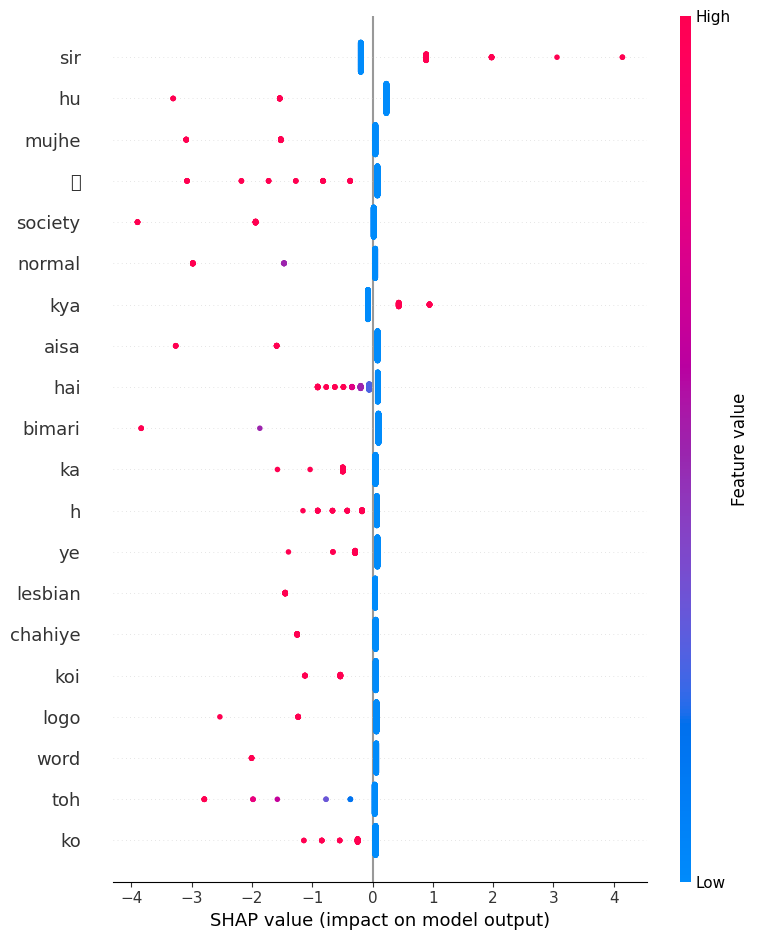

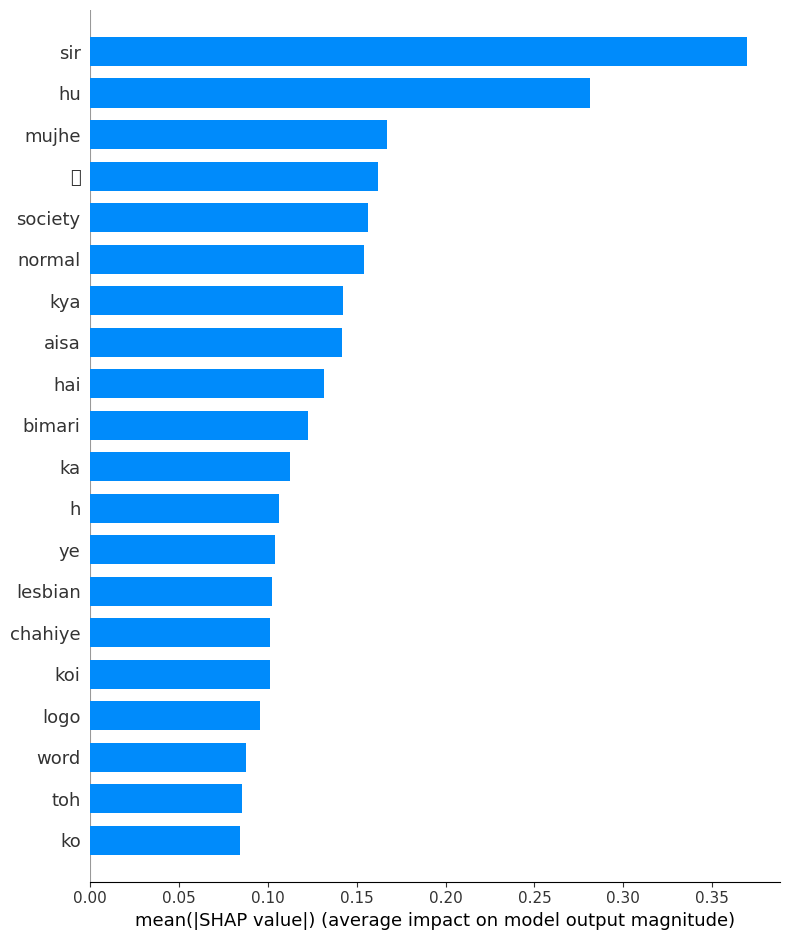

In [ ]:
explainer_logreg_bow, shap_values_logreg_bow = explainable_AI(logreg_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.6045
Precision: 0.5648
Recall: 0.9104
F1-score: 0.6971
Confusion Matrix:
[[ 80 188]
 [ 24 244]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.30      0.43       268
           1       0.56      0.91      0.70       268

    accuracy                           0.60       536
   macro avg       0.67      0.60      0.56       536
weighted avg       0.67      0.60      0.56       536



Summary plot as a whole:


Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.


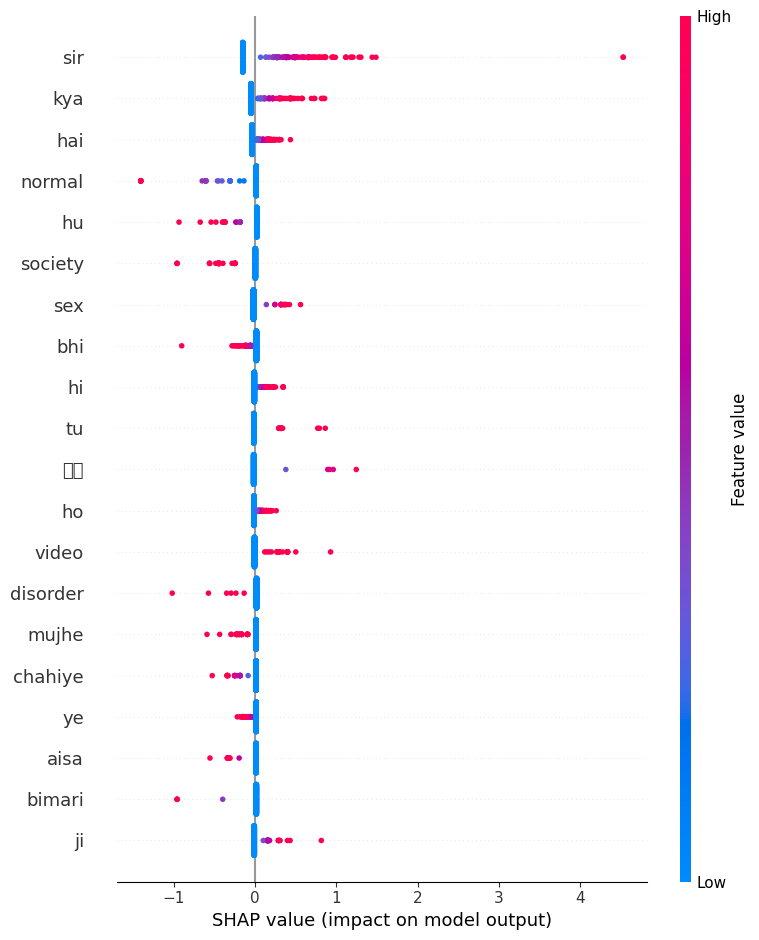

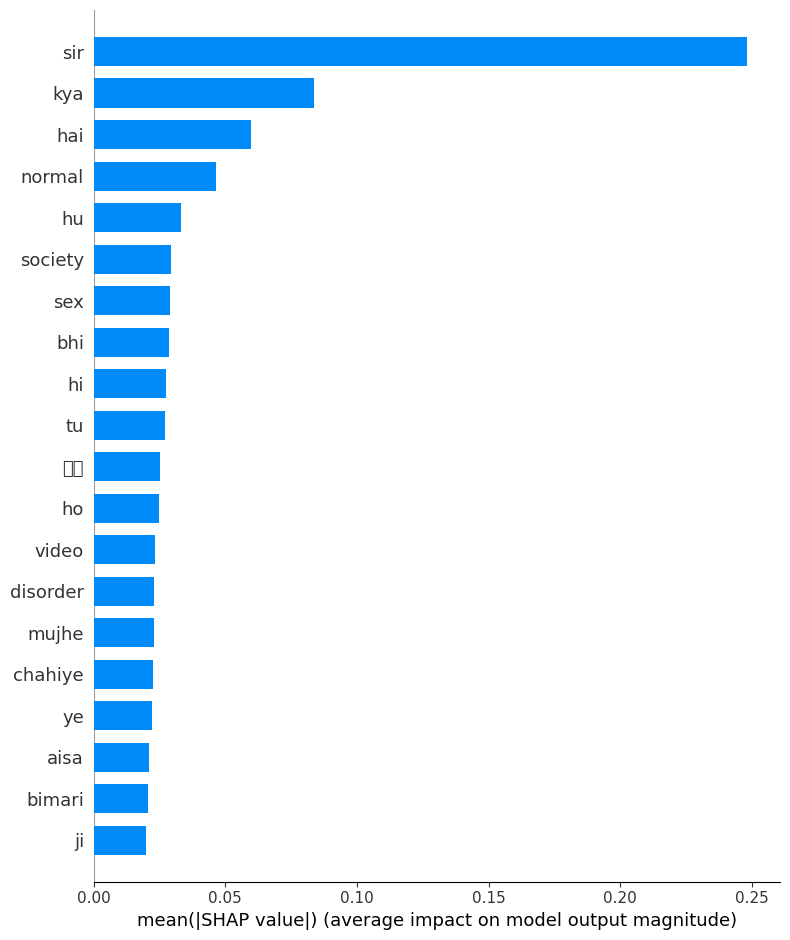

In [ ]:
explainer_logreg_tfidf, shap_values_logreg_tfidf = explainable_AI(logreg_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Linear SVC

In [ ]:
linear_svc_model = LinearSVC(random_state=42)
linear_svc_model.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_svc = linear_svc_model.predict(X_test_mybag)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_svc)
y_test_svc = [label for label in decoded_y_test]
y_test_predicted_labels_svc

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0])

In [ ]:
np.unique(y_test_svc)

array(['Hope', 'Not-Hope'], dtype='<U8')

In [ ]:
df_test_undersampled['label'] = y_test_svc
df_test_undersampled['label']

0          Hope
1          Hope
2          Hope
3          Hope
4      Not-Hope
         ...   
101        Hope
102        Hope
103    Not-Hope
104    Not-Hope
105        Hope
Name: label, Length: 106, dtype: object

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svc)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svc, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.7547
Precision: 0.7455
Recall: 0.7736
F1-score: 0.7593


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svc)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svc)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[39 14]
 [12 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        53
           1       0.75      0.77      0.76        53

    accuracy                           0.75       106
   macro avg       0.76      0.75      0.75       106
weighted avg       0.76      0.75      0.75       106



# Multinomial Naive Bayes

In [ ]:
# Train Multinomial Naive Bayes model
mnb_model = MultinomialNB()
mnb_model.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_mnb = mnb_model.predict(X_test_mybag)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_mnb)
y_test_mnb = [label for label in decoded_y_test]
y_test_predicted_labels_mnb

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mnb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mnb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5849
Precision: 0.8462
Recall: 0.2075
F1-score: 0.3333


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mnb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mnb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[51  2]
 [42 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.96      0.70        53
           1       0.85      0.21      0.33        53

    accuracy                           0.58       106
   macro avg       0.70      0.58      0.52       106
weighted avg       0.70      0.58      0.52       106



# XG Boost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert data to DMatrix format used by XGBoost
dtrain = xgb.DMatrix(X_train_mybag, label=y_train)
dtest = xgb.DMatrix(X_test_mybag)

# Set XGBoost parameters (you may adjust these based on your needs)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.01,
    'n_estimators': 50,
    'seed': 42
}

# Train XGBoost model
xgb_model = xgb.train(params, dtrain)

# Predict labels for the test set
y_test_predicted_labels_xgb = xgb_model.predict(dtest)
y_test_predicted_labels_xgb = [1 if pred > 0.5 else 0 for pred in y_test_predicted_labels_xgb]

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [13:44:41] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_xgb)
y_test_xgb = [label for label in decoded_y_test]
y_test_predicted_labels_xgb

[1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0]

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_xgb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_xgb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.5472
Precision: 0.5333
Recall: 0.7547
F1-score: 0.6250


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_xgb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_xgb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[18 35]
 [13 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.34      0.43        53
           1       0.53      0.75      0.62        53

    accuracy                           0.55       106
   macro avg       0.56      0.55      0.53       106
weighted avg       0.56      0.55      0.53       106



# Ada Boost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train AdaBoost model
adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_adaboost = adaboost_model.predict(X_test_mybag)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_adaboost)
y_test_adaboost = [label for label in decoded_y_test]
y_test_predicted_labels_adaboost

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_adaboost)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_adaboost, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6792
Precision: 0.6557
Recall: 0.7547
F1-score: 0.7018


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_adaboost)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_adaboost)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[32 21]
 [13 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        53
           1       0.66      0.75      0.70        53

    accuracy                           0.68       106
   macro avg       0.68      0.68      0.68       106
weighted avg       0.68      0.68      0.68       106



# Decision Tree

In [ ]:
# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_tree = decision_tree_model.predict(X_test_mybag)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_tree)
y_test_tree = [label for label in decoded_y_test]
y_test_predicted_labels_tree

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_tree)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_tree, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6698
Precision: 0.6731
Recall: 0.6604
F1-score: 0.6667


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrixx
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_tree)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_tree)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[36 17]
 [18 35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.68      0.67        53
           1       0.67      0.66      0.67        53

    accuracy                           0.67       106
   macro avg       0.67      0.67      0.67       106
weighted avg       0.67      0.67      0.67       106



# Gradient Boosting

In [ ]:
# Train Gradient Boosting model
gradient_boosting_model = GradientBoostingClassifier(random_state=42)
gradient_boosting_model.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_gb = gradient_boosting_model.predict(X_test_mybag)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_gb)
y_test_gb = [label for label in decoded_y_test]
y_test_predicted_labels_gb

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_gb)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_gb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.7264
Precision: 0.7143
Recall: 0.7547
F1-score: 0.7339


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_gb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_gb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[37 16]
 [13 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        53
           1       0.71      0.75      0.73        53

    accuracy                           0.73       106
   macro avg       0.73      0.73      0.73       106
weighted avg       0.73      0.73      0.73       106



# SVM

In [ ]:
from sklearn.svm import SVC
svm_model = SVC(random_state=42)
svm_model.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_svm = svm_model.predict(X_test_mybag)

In [ ]:
decoded_y_test= encoder.inverse_transform(y_test_predicted_labels_svm)
y_test_svm = [label for label in decoded_y_test]
y_test_predicted_labels_svm

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0])

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svm)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svm, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Accuracy: 0.6698
Precision: 0.6452
Recall: 0.7547
F1-score: 0.6957


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svm)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svm)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[31 22]
 [13 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.58      0.64        53
           1       0.65      0.75      0.70        53

    accuracy                           0.67       106
   macro avg       0.67      0.67      0.67       106
weighted avg       0.67      0.67      0.67       106



# Ridge Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_bow = RidgeClassifier(random_state=42)
ridge_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_mybag = ridge_classifier_model_bow.predict(X_test_mybag)

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_tfidf = RidgeClassifier(random_state=42)
ridge_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_tfidf = ridge_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_ridge_mybag)
y_test_ridge_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_ridge_mybag

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_ridge_tfidf)
y_test_ridge_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_ridge_tfidf

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.6138
Precision: 0.5708
Recall: 0.9179
F1-score: 0.7039
Confusion Matrix:
[[ 83 185]
 [ 22 246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.31      0.45       268
           1       0.57      0.92      0.70       268

    accuracy                           0.61       536
   macro avg       0.68      0.61      0.57       536
weighted avg       0.68      0.61      0.57       536



Summary plot as a whole:


Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Matplotlib currently does not support Devanagari natively.


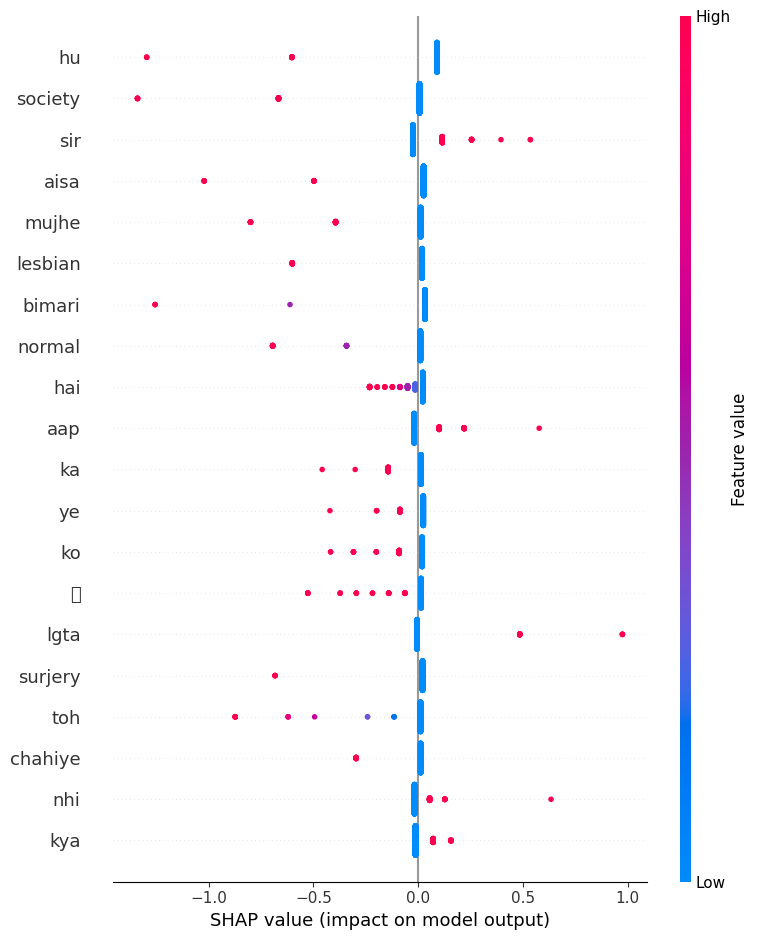

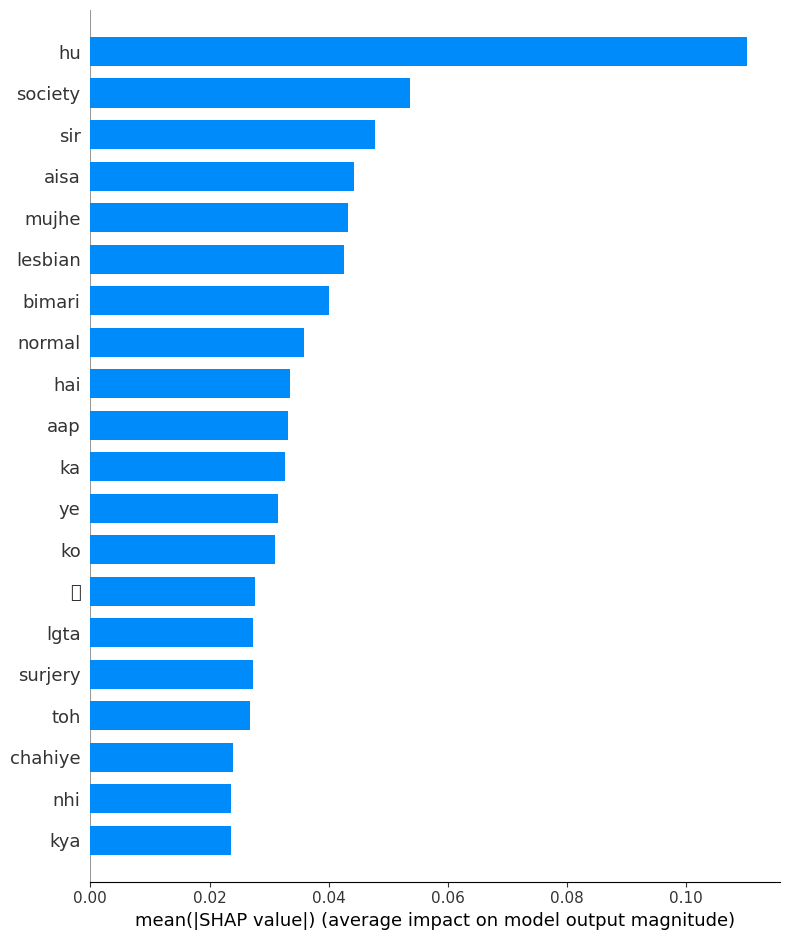

In [ ]:
explainer_ridge_bow, shap_values_ridge_bow = explainable_AI(ridge_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF result:

Accuracy: 0.6063
Precision: 0.5638
Recall: 0.9403
F1-score: 0.7049
Confusion Matrix:
[[ 73 195]
 [ 16 252]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.27      0.41       268
           1       0.56      0.94      0.70       268

    accuracy                           0.61       536
   macro avg       0.69      0.61      0.56       536
weighted avg       0.69      0.61      0.56       536



Summary plot as a whole:


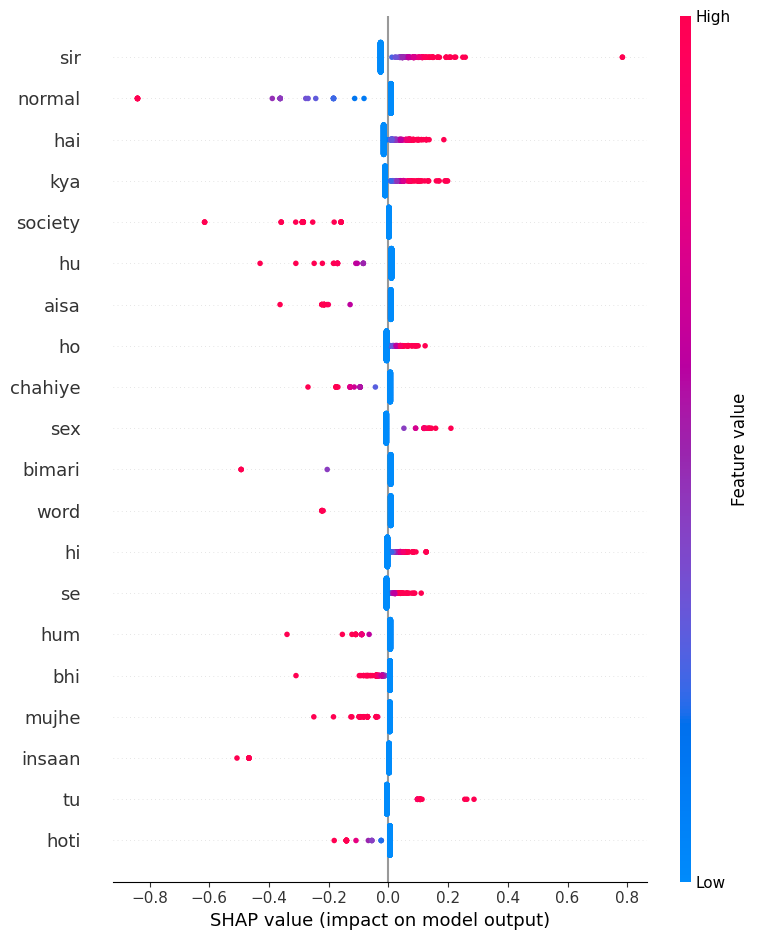

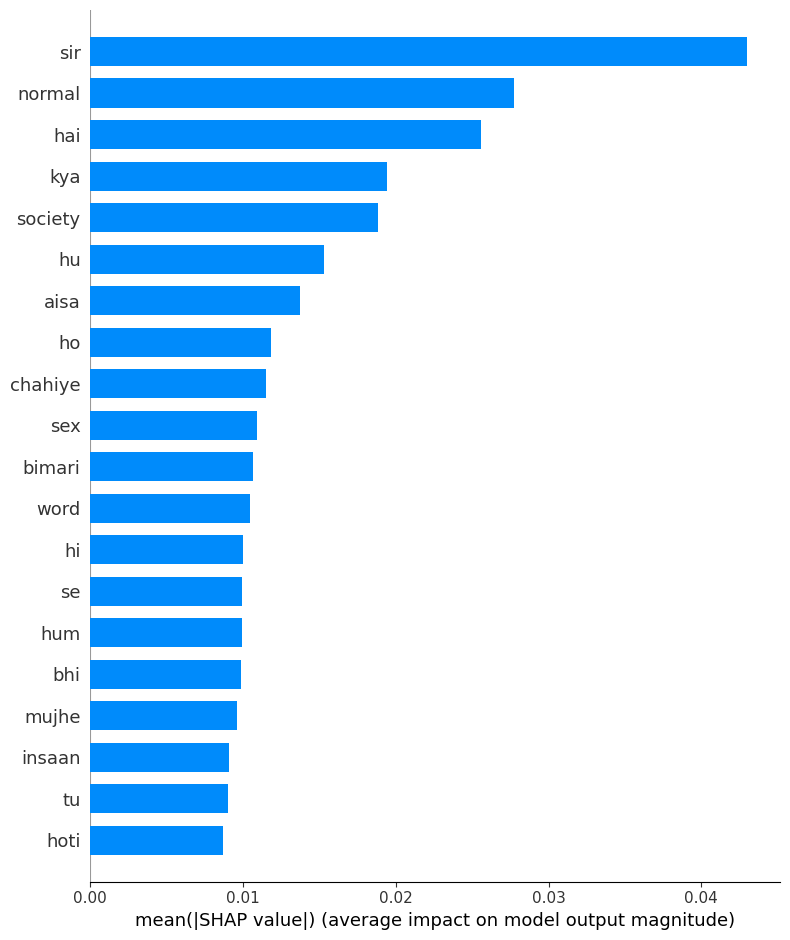

In [ ]:
explainer_ridge_tfidf, shap_values_ridge_tfidf = explainable_AI(ridge_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Perceptron Classifier

In [ ]:
from sklearn.linear_model import Perceptron

# Train Perceptron model
perceptron_model_bow = Perceptron(random_state=42)
perceptron_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_mybag = perceptron_model_bow.predict(X_test_mybag)


In [ ]:
# Train Perceptron model
perceptron_model_tfidf = Perceptron(random_state=42)
perceptron_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_tfidf = perceptron_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_perceptron_mybag)
y_test_perceptron_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_perceptron_mybag

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_perceptron_tfidf)
y_test_perceptron_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_perceptron_tfidf

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.5989
Precision: 0.5635
Recall: 0.8769
F1-score: 0.6861
Confusion Matrix:
[[ 86 182]
 [ 33 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.32      0.44       268
           1       0.56      0.88      0.69       268

    accuracy                           0.60       536
   macro avg       0.64      0.60      0.57       536
weighted avg       0.64      0.60      0.57       536



Summary plot as a whole:


Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.


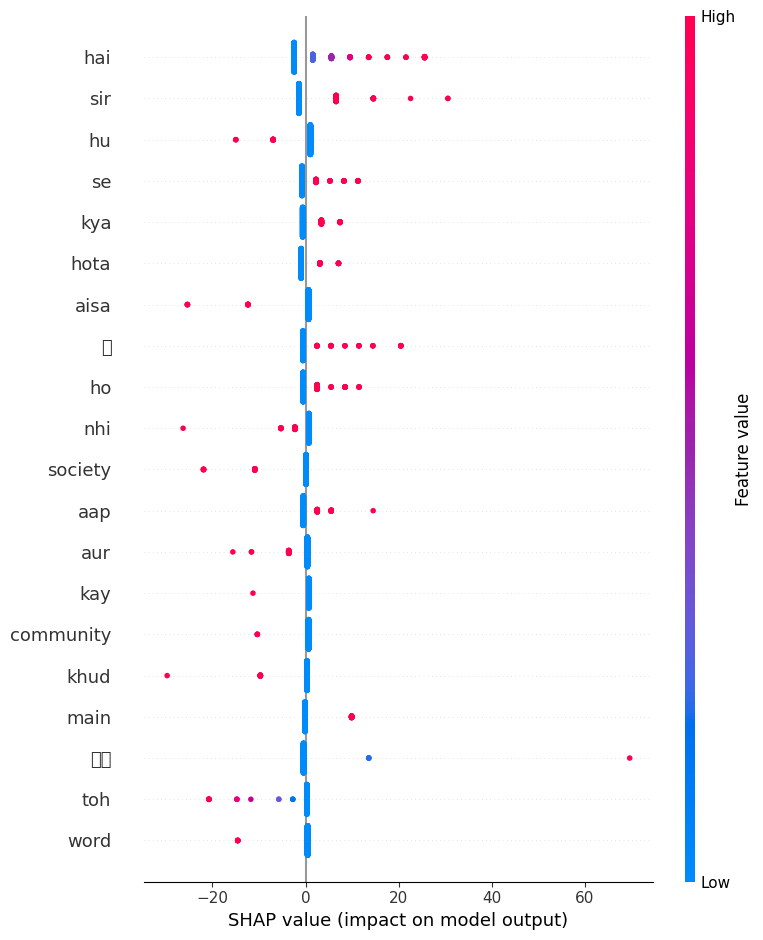

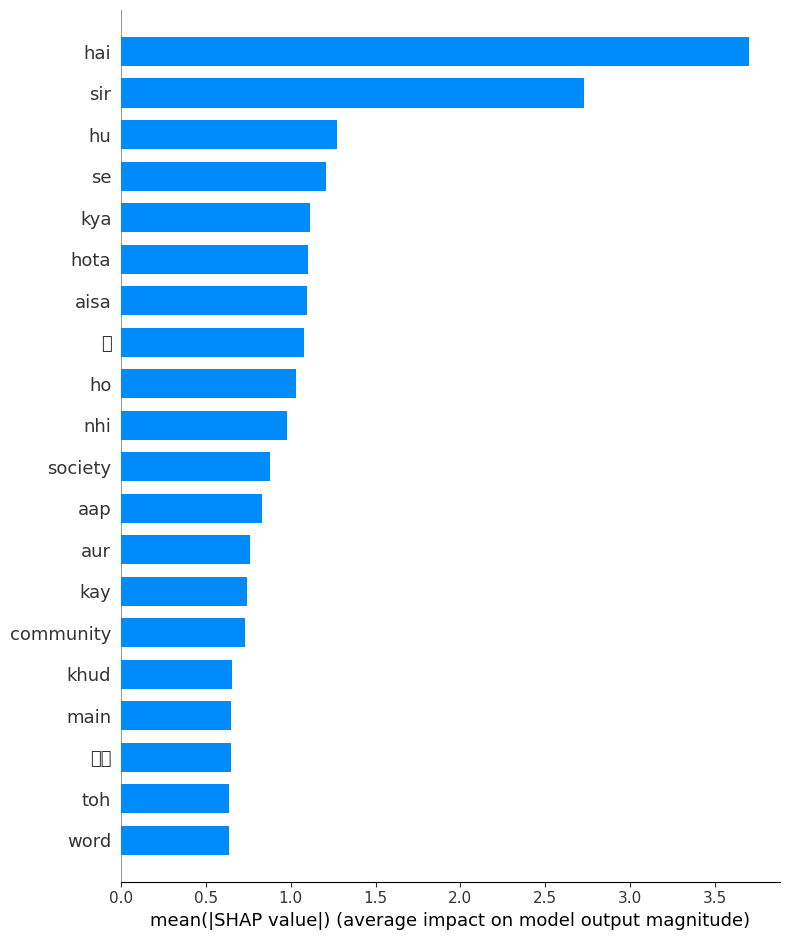

In [ ]:
explainer_perceptron_bow, shap_values_perceptron_bow = explainable_AI(perceptron_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.5765
Precision: 0.5465
Recall: 0.8993
F1-score: 0.6798
Confusion Matrix:
[[ 68 200]
 [ 27 241]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.25      0.37       268
           1       0.55      0.90      0.68       268

    accuracy                           0.58       536
   macro avg       0.63      0.58      0.53       536
weighted avg       0.63      0.58      0.53       536



Summary plot as a whole:


Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.


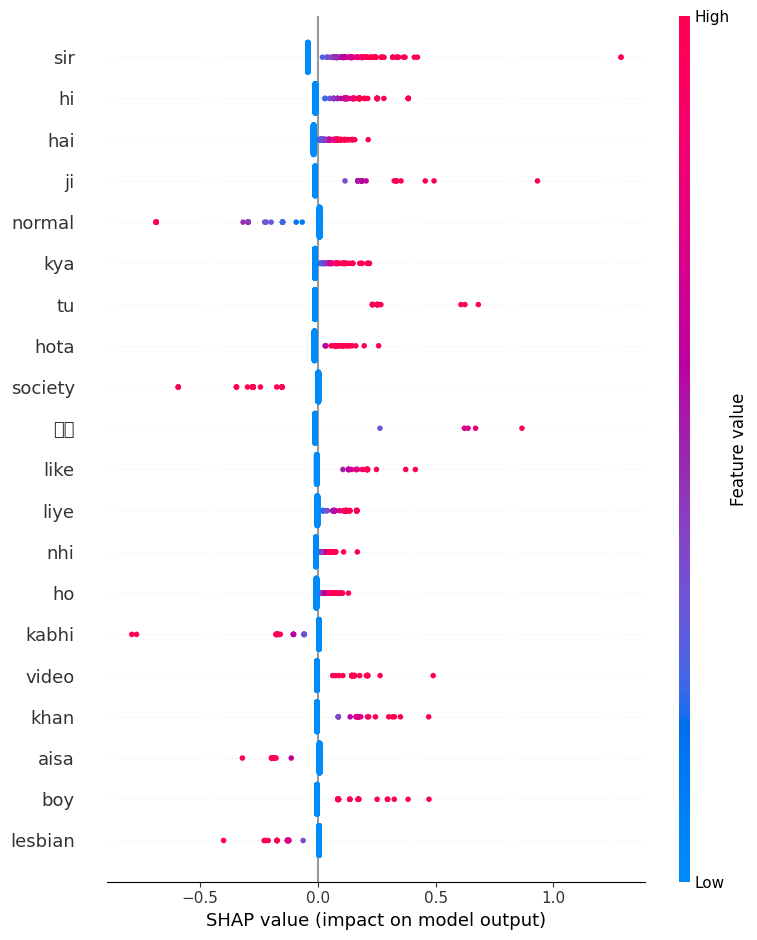

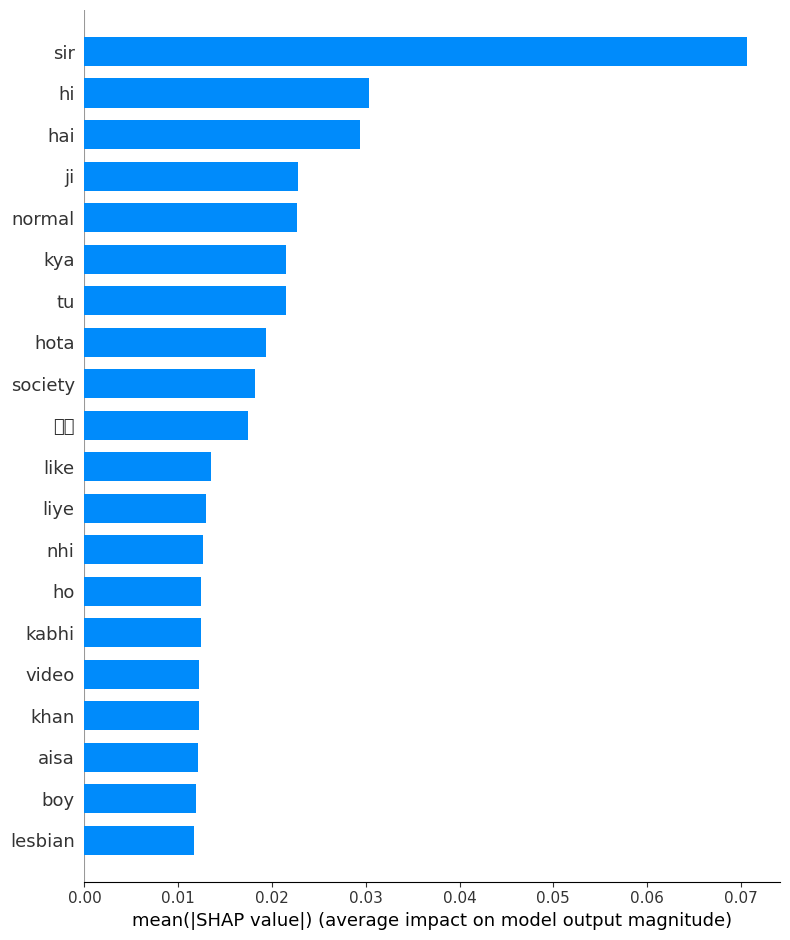

In [ ]:
explainer_perceptron_tfidf, shap_values_perceptron_tfidf = explainable_AI(perceptron_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# SGD classifier

In [ ]:
from sklearn.linear_model import SGDClassifier

# Train SGD Classifier model
sgd_classifier_model_bow = SGDClassifier(random_state=42)
sgd_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_mybag = sgd_classifier_model_bow.predict(X_test_mybag)


In [ ]:
# Train SGD Classifier model
sgd_classifier_model_tfidf = SGDClassifier(random_state=42)
sgd_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_tfidf = sgd_classifier_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_sgd_mybag)
y_test_sgd_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_sgd_mybag

array([1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_sgd_tfidf)
y_test_sgd_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_sgd_tfidf

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.6157
Precision: 0.5749
Recall: 0.8881
F1-score: 0.6979
Confusion Matrix:
[[ 92 176]
 [ 30 238]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.34      0.47       268
           1       0.57      0.89      0.70       268

    accuracy                           0.62       536
   macro avg       0.66      0.62      0.58       536
weighted avg       0.66      0.62      0.58       536



Summary plot as a whole:


Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Matplotlib currently does not support Devanagari natively.


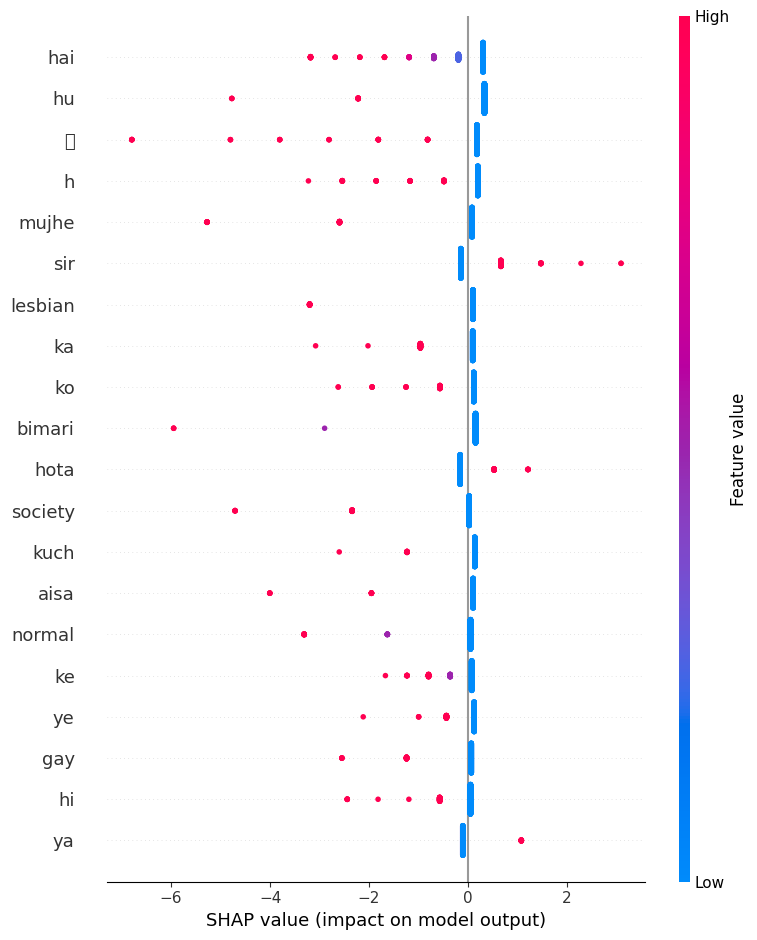

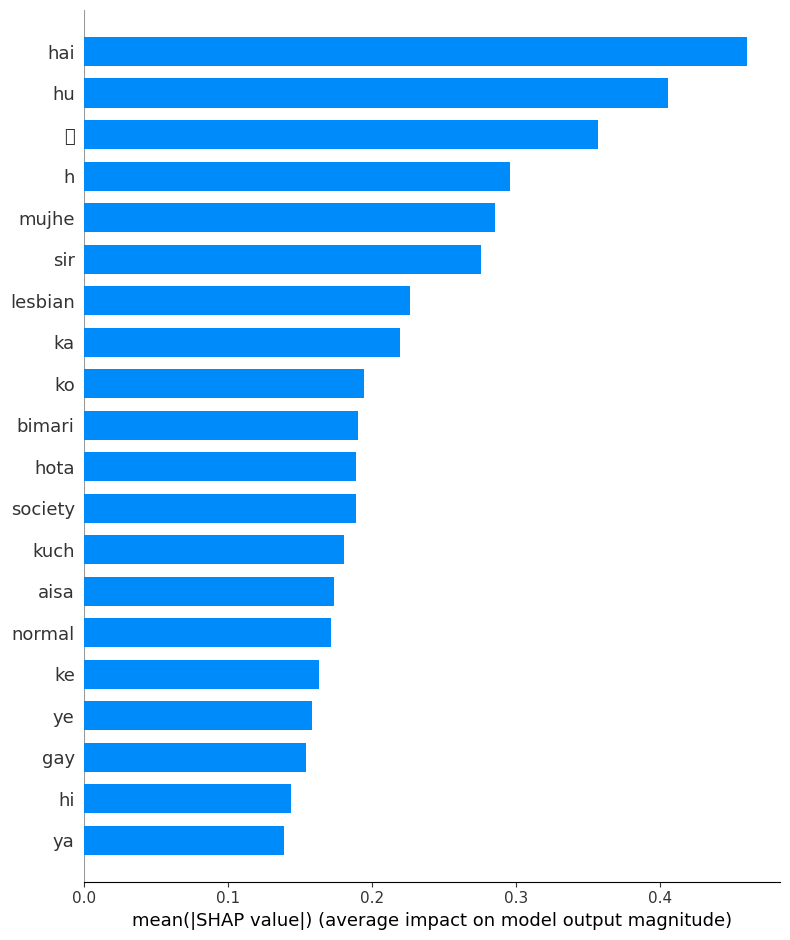

In [ ]:
explainer_sgd_bow, shap_values_sgd_bow = explainable_AI(sgd_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF result:

Accuracy: 0.5858
Precision: 0.5498
Recall: 0.9478
F1-score: 0.6959
Confusion Matrix:
[[ 60 208]
 [ 14 254]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.22      0.35       268
           1       0.55      0.95      0.70       268

    accuracy                           0.59       536
   macro avg       0.68      0.59      0.52       536
weighted avg       0.68      0.59      0.52       536



Summary plot as a whole:


Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.


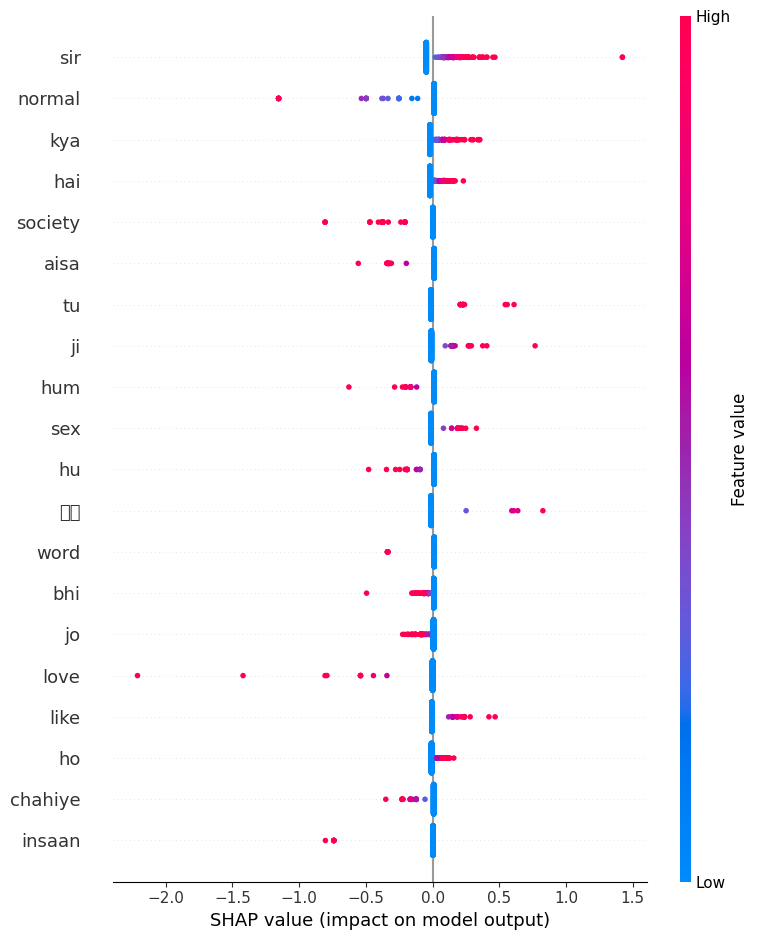

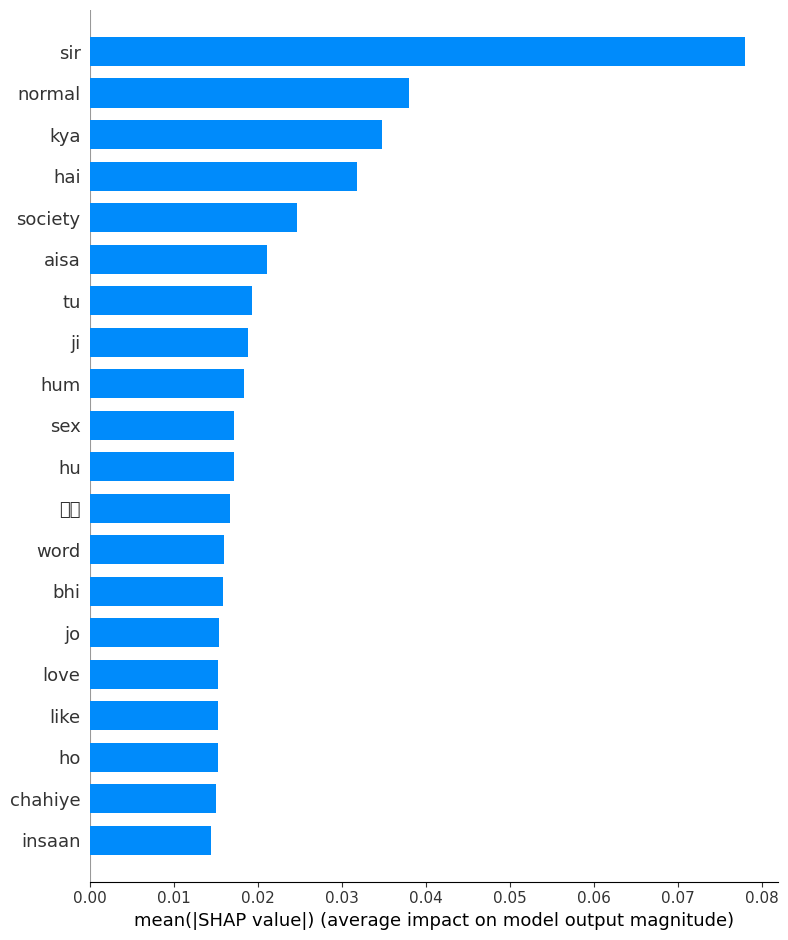

In [ ]:
explainer_sgd_tfidf, shap_values_sgd_tfidf = explainable_AI(sgd_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Passive Aggressive Classifier

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Train Passive Aggressive Classifier model
pa_classifier_model_bow = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_mybag = pa_classifier_model_bow.predict(X_test_mybag)

In [ ]:
# Train Passive Aggressive Classifier model
pa_classifier_model_tfidf = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_tfidf = pa_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_pa_mybag)
y_test_pa_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_pa_mybag

array([0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_pa_tfidf)
y_test_pa_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_pa_tfidf

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



Bag of words result:

Accuracy: 0.6381
Precision: 0.5894
Recall: 0.9104
F1-score: 0.7155
Confusion Matrix:
[[ 98 170]
 [ 24 244]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.37      0.50       268
           1       0.59      0.91      0.72       268

    accuracy                           0.64       536
   macro avg       0.70      0.64      0.61       536
weighted avg       0.70      0.64      0.61       536



Summary plot as a whole:


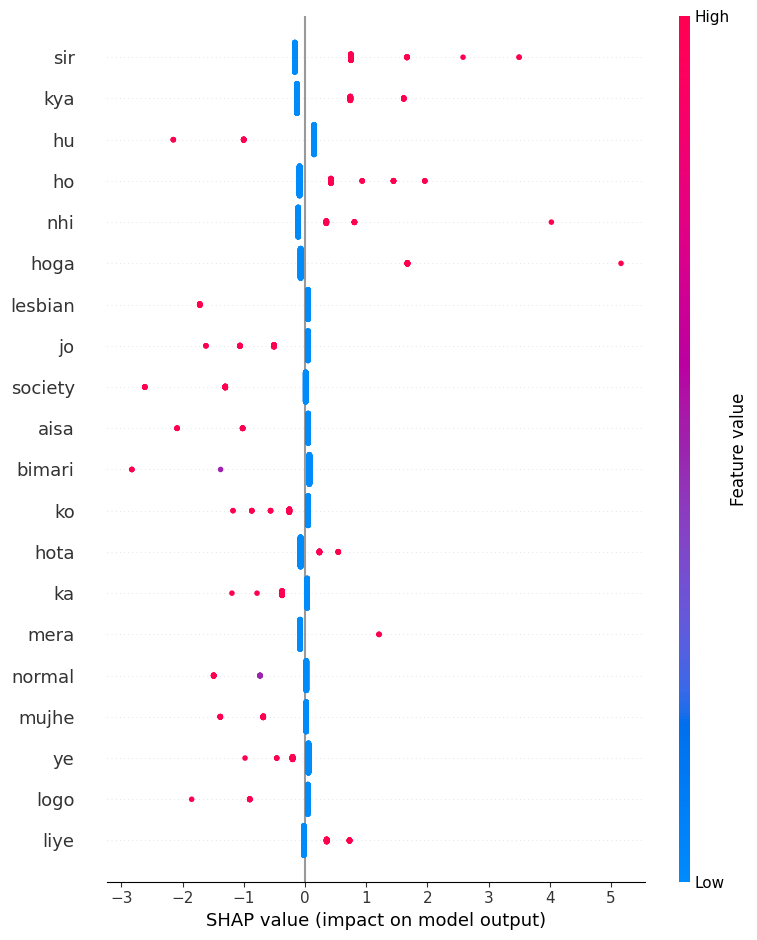

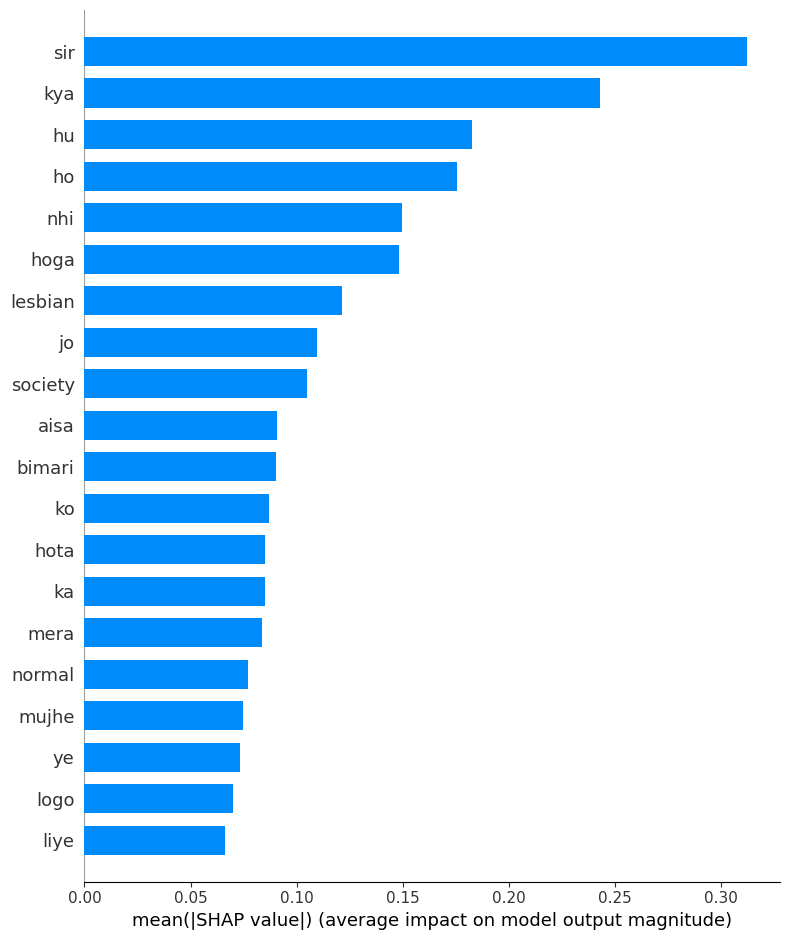

In [ ]:
explainer_pa_bow, shap_values_pa_bow = explainable_AI(pa_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



TFIDF result:

Accuracy: 0.5802
Precision: 0.5464
Recall: 0.9440
F1-score: 0.6922
Confusion Matrix:
[[ 58 210]
 [ 15 253]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.22      0.34       268
           1       0.55      0.94      0.69       268

    accuracy                           0.58       536
   macro avg       0.67      0.58      0.52       536
weighted avg       0.67      0.58      0.52       536



Summary plot as a whole:


Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.


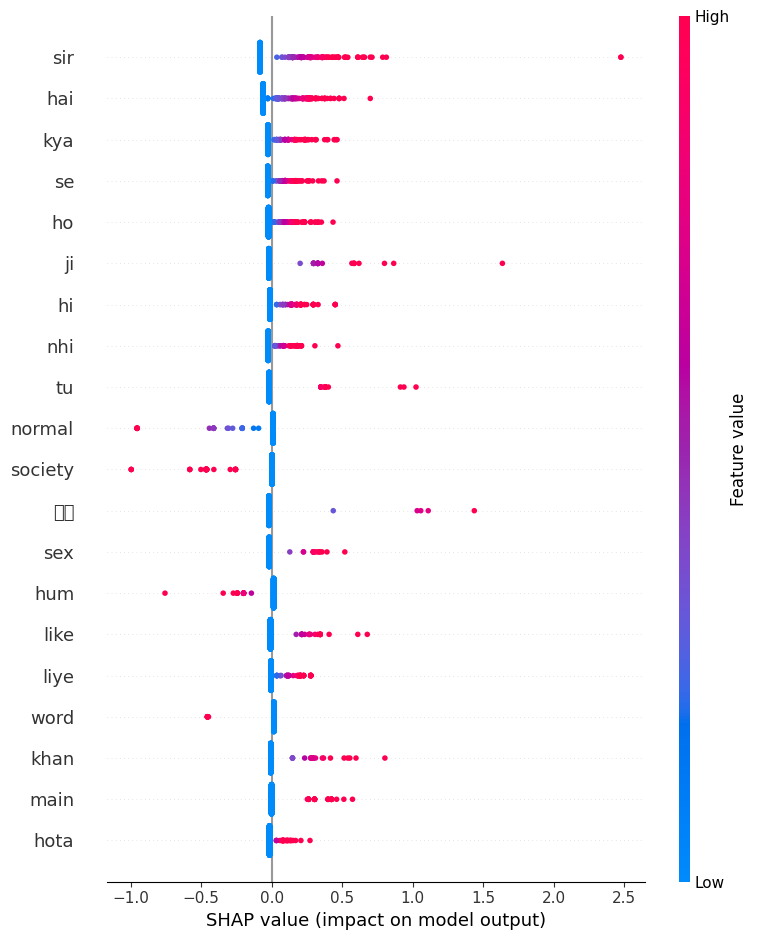

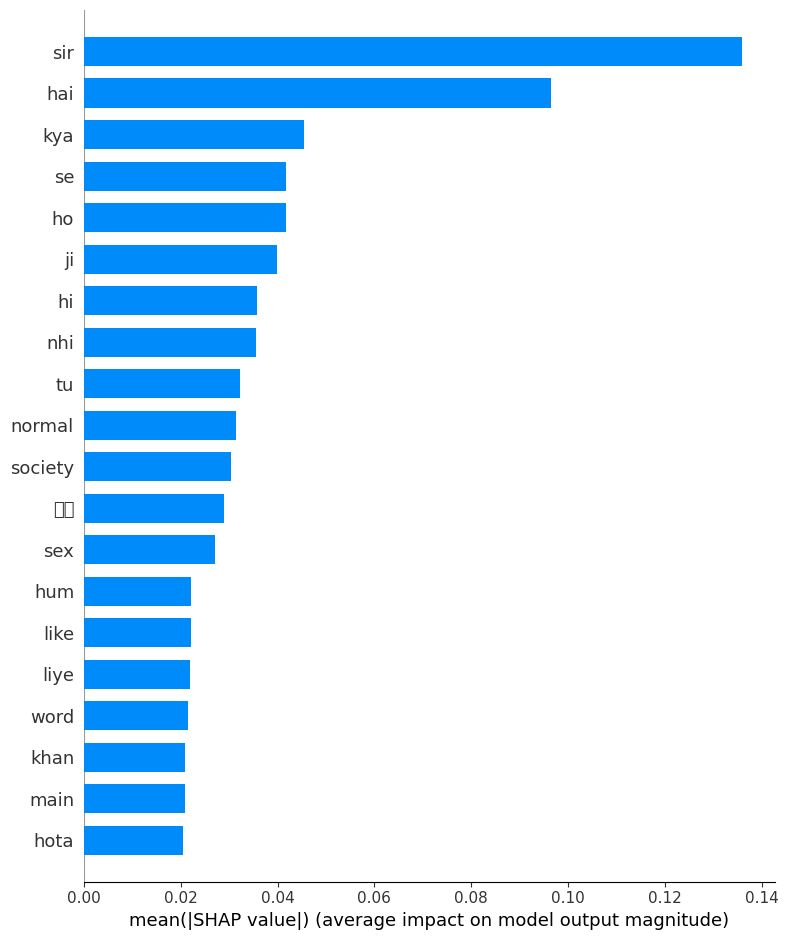

In [ ]:
explainer_pa_tfidf, shap_values_pa_tfidf = explainable_AI(pa_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Deep Learning Models

# CNN

In [ ]:
pip install tensorflow

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd

# Assuming df_test_labels contains the true labels for the test set
# df_test_labels = pd.read_csv("/content/english/Hope_eng_test_with_labels.csv", index_col=0)
# y_true = df_test_labels['Labels']

# Tokenize and pad sequences
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Create a LabelEncoder and fit on the true labels
encoder = LabelEncoder()
encoder_2 = LabelEncoder()
y_train_encoded = encoder_2.fit_transform(y_train)
encoder.fit(y_true)

# Build CNN model
model = Sequential()
model.add(Embedding(max_words, 50, input_length=max_len))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Convert true labels to numeric values
y_true_numeric = encoder.transform(y_true)

# Predict on the test set
y_test_probabilities = model.predict(X_test_pad)
y_test_predicted_labels_cnn = (y_test_probabilities > 0.5).astype(int)

# Convert predicted labels back to original labels
y_test_predicted_labels_cnn_str = encoder.inverse_transform(y_test_predicted_labels_cnn.flatten())

# Evaluate the model
accuracy_cnn = accuracy_score(y_true_numeric, y_test_predicted_labels_cnn)
precision_cnn = precision_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
recall_cnn = recall_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
f1_cnn = f1_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)

# Print the results
print(f"Accuracy: {accuracy_cnn:.4f}")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall: {recall_cnn:.4f}")
print(f"F1-score: {f1_cnn:.4f}")


Epoch 1/10
20/20 [==============================] - 7s 107ms/step - loss: 0.6325 - accuracy: 0.6419 - val_loss: 1.0434 - val_accuracy: 0.1218
Epoch 2/10
20/20 [==============================] - 1s 74ms/step - loss: 0.4982 - accuracy: 0.7629 - val_loss: 0.5495 - val_accuracy: 0.7500
Epoch 3/10
20/20 [==============================] - 1s 59ms/step - loss: 0.3378 - accuracy: 0.8726 - val_loss: 0.7931 - val_accuracy: 0.6154
Epoch 4/10
20/20 [==============================] - 1s 75ms/step - loss: 0.1906 - accuracy: 0.9371 - val_loss: 1.1953 - val_accuracy: 0.5641
Epoch 5/10
20/20 [==============================] - 2s 96ms/step - loss: 0.1052 - accuracy: 0.9726 - val_loss: 1.1276 - val_accuracy: 0.6346
Epoch 6/10
20/20 [==============================] - 2s 90ms/step - loss: 0.0743 - accuracy: 0.9774 - val_loss: 1.8719 - val_accuracy: 0.4872
Epoch 7/10
20/20 [==============================] - 2s 97ms/step - loss: 0.0592 - accuracy: 0.9806 - val_loss: 2.8722 - val_accuracy: 0.3205
Epoch 8/10
2

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_cnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_cnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[40 13]
 [16 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        53
           1       0.74      0.70      0.72        53

    accuracy                           0.73       106
   macro avg       0.73      0.73      0.73       106
weighted avg       0.73      0.73      0.73       106



PermutationExplainer explainer: 107it [12:42,  7.19s/it]


Summary plot as a whole:


Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.


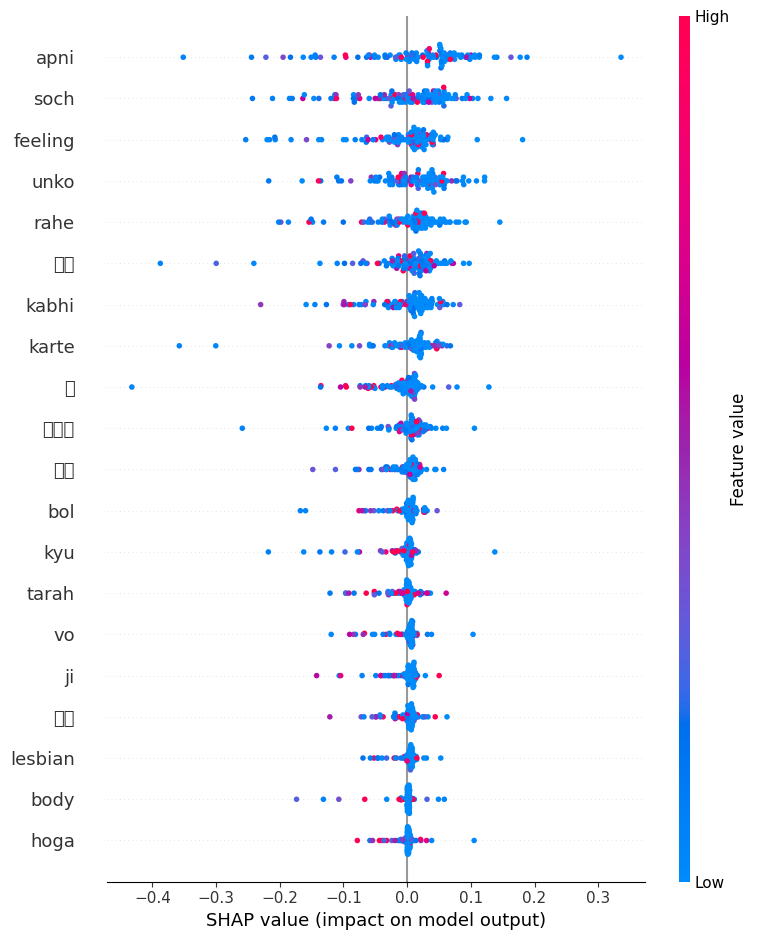

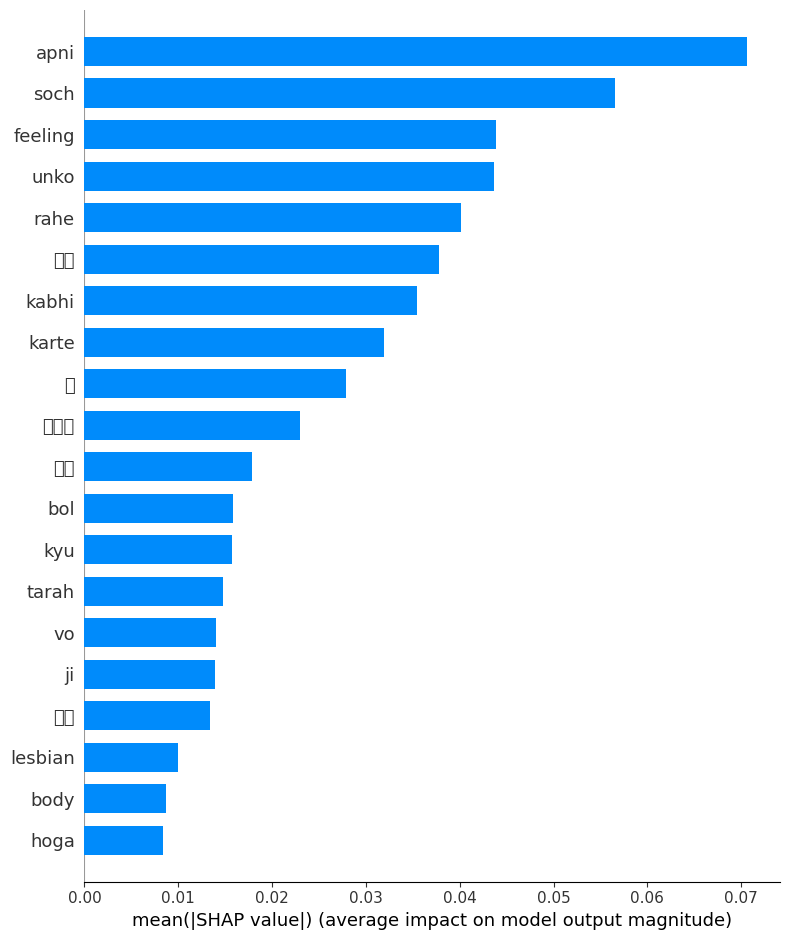

In [ ]:
explainer_cnn, shap_values_cnn = explainable_AI(model,X_train_pad,list(ALL_WORDS),X_test_pad,shap.Explainer,False)

# LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, return_sequences=True))  # Add return_sequences=True for stacking LSTM layers
# model.add(Dropout(0.2))  # Dropout for regularization
model.add(LSTM(100))
# model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob = model.predict(X_test_seq)
y_test_pred = (y_test_prob > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_lstm = accuracy_score(y_true_numeric, y_test_pred)
precision_lstm = precision_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
recall_lstm = recall_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
f1_lstm = f1_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall: {recall_lstm:.4f}")
print(f"F1 Score: {f1_lstm:.4f}")


Epoch 1/10
20/20 [==============================] - 12s 368ms/step - loss: 0.6461 - accuracy: 0.6403 - val_loss: 0.8505 - val_accuracy: 0.5962
Epoch 2/10
20/20 [==============================] - 5s 241ms/step - loss: 0.5337 - accuracy: 0.7339 - val_loss: 0.7218 - val_accuracy: 0.5962
Epoch 3/10
20/20 [==============================] - 5s 233ms/step - loss: 0.3727 - accuracy: 0.8403 - val_loss: 0.6386 - val_accuracy: 0.7372
Epoch 4/10
20/20 [==============================] - 7s 358ms/step - loss: 0.1601 - accuracy: 0.9355 - val_loss: 1.6509 - val_accuracy: 0.5385
Epoch 5/10
20/20 [==============================] - 5s 232ms/step - loss: 0.0610 - accuracy: 0.9806 - val_loss: 2.5478 - val_accuracy: 0.4872
Epoch 6/10
20/20 [==============================] - 5s 247ms/step - loss: 0.0401 - accuracy: 0.9871 - val_loss: 1.9079 - val_accuracy: 0.5128
Epoch 7/10
20/20 [==============================] - 6s 313ms/step - loss: 0.0258 - accuracy: 0.9903 - val_loss: 2.4229 - val_accuracy: 0.5000
Epoch

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix.
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[47  6]
 [24 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.89      0.76        53
           1       0.83      0.55      0.66        53

    accuracy                           0.72       106
   macro avg       0.75      0.72      0.71       106
weighted avg       0.75      0.72      0.71       106



PermutationExplainer explainer: 107it [1:28:26, 50.06s/it]


Summary plot as a whole:


Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA})

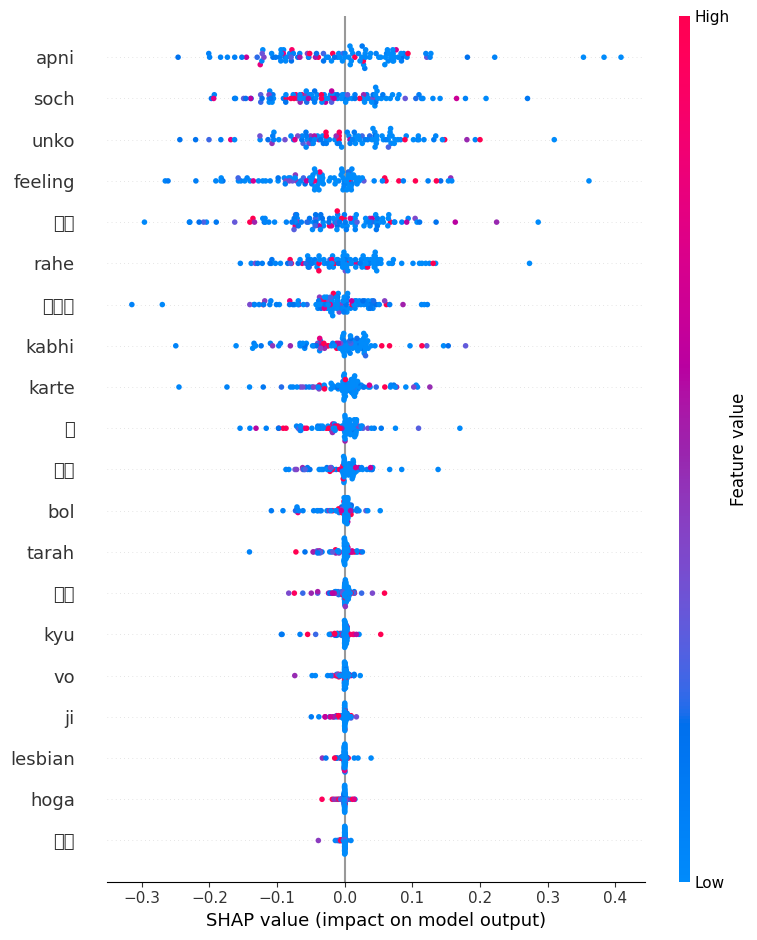

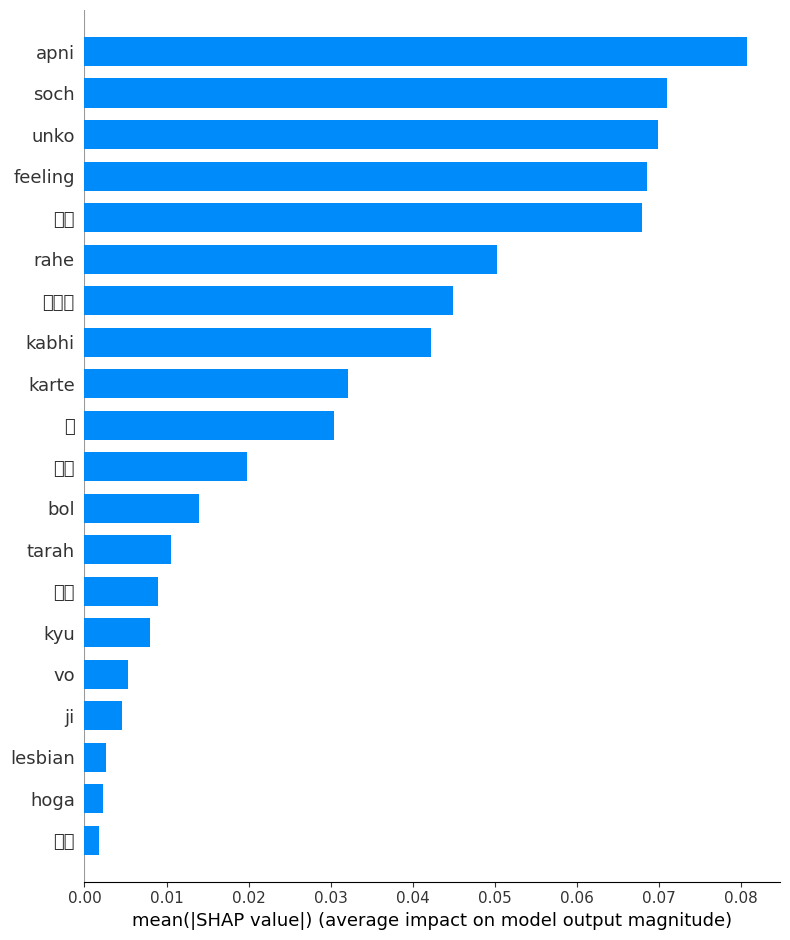

In [ ]:
explainer_lstm, shap_values_lstm = explainable_AI(model,X_train_seq,list(ALL_WORDS),X_test_seq,shap.Explainer,False)

# Bi-LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the bi-LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(Bidirectional(LSTM(100)))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob_bilstm = model.predict(X_test_seq)
y_test_pred_bilstm = (y_test_prob_bilstm > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_bilstm = accuracy_score(y_true_numeric, y_test_pred_bilstm)
precision_bilstm = precision_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
recall_bilstm = recall_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
f1_bilstm = f1_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_bilstm:.4f}")
print(f"Precision: {precision_bilstm:.4f}")
print(f"Recall: {recall_bilstm:.4f}")
print(f"F1 Score: {f1_bilstm:.4f}")


Epoch 1/10
20/20 [==============================] - 11s 276ms/step - loss: 0.6602 - accuracy: 0.6161 - val_loss: 0.7865 - val_accuracy: 0.5577
Epoch 2/10
20/20 [==============================] - 4s 197ms/step - loss: 0.5328 - accuracy: 0.7355 - val_loss: 0.5375 - val_accuracy: 0.7692
Epoch 3/10
20/20 [==============================] - 5s 279ms/step - loss: 0.3892 - accuracy: 0.8290 - val_loss: 0.8800 - val_accuracy: 0.6346
Epoch 4/10
20/20 [==============================] - 5s 247ms/step - loss: 0.1915 - accuracy: 0.9226 - val_loss: 1.2983 - val_accuracy: 0.4679
Epoch 5/10
20/20 [==============================] - 4s 198ms/step - loss: 0.0659 - accuracy: 0.9823 - val_loss: 2.9362 - val_accuracy: 0.3205
Epoch 6/10
20/20 [==============================] - 4s 216ms/step - loss: 0.0716 - accuracy: 0.9823 - val_loss: 1.6050 - val_accuracy: 0.4295
Epoch 7/10
20/20 [==============================] - 6s 308ms/step - loss: 0.0434 - accuracy: 0.9855 - val_loss: 2.2962 - val_accuracy: 0.4038
Epoch

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred_bilstm)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred_bilstm)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[43 10]
 [20 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.81      0.74        53
           1       0.77      0.62      0.69        53

    accuracy                           0.72       106
   macro avg       0.72      0.72      0.71       106
weighted avg       0.72      0.72      0.71       106



# Simple RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the RNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(SimpleRNN(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_rnn = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_rnn)
precision = precision_score(y_true_numeric, y_pred_rnn, average='binary')
recall = recall_score(y_true_numeric, y_pred_rnn, average='binary')
f1 = f1_score(y_true_numeric, y_pred_rnn, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
10/10 [==============================] - 2s 80ms/step - loss: 0.6878 - accuracy: 0.5613 - val_loss: 0.7339 - val_accuracy: 0.0641
Epoch 2/10
10/10 [==============================] - 0s 49ms/step - loss: 0.6373 - accuracy: 0.6855 - val_loss: 0.9417 - val_accuracy: 0.0641
Epoch 3/10
10/10 [==============================] - 1s 52ms/step - loss: 0.5469 - accuracy: 0.7516 - val_loss: 0.8497 - val_accuracy: 0.1474
Epoch 4/10
10/10 [==============================] - 0s 50ms/step - loss: 0.4586 - accuracy: 0.8484 - val_loss: 1.0974 - val_accuracy: 0.2500
Epoch 5/10
10/10 [==============================] - 1s 51ms/step - loss: 0.3368 - accuracy: 0.8726 - val_loss: 0.9355 - val_accuracy: 0.5321
Epoch 6/10
10/10 [==============================] - 0s 50ms/step - loss: 0.2205 - accuracy: 0.9468 - val_loss: 0.7289 - val_accuracy: 0.6218
Epoch 7/10
10/10 [==============================] - 0s 48ms/step - loss: 0.1476 - accuracy: 0.9645 - val_loss: 0.7110 - val_accuracy: 0.6474
Epoch 8/10
10

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_rnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_rnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[ 40 228]
 [ 12 256]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.15      0.25       268
           1       0.53      0.96      0.68       268

    accuracy                           0.55       536
   macro avg       0.65      0.55      0.47       536
weighted avg       0.65      0.55      0.47       536



# DNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn)
precision = precision_score(y_true_numeric, y_pred_dnn, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
10/10 [==============================] - 3s 121ms/step - loss: 0.6829 - accuracy: 0.5984 - val_loss: 0.7154 - val_accuracy: 0.5321
Epoch 2/10
10/10 [==============================] - 1s 128ms/step - loss: 0.6589 - accuracy: 0.6129 - val_loss: 0.8497 - val_accuracy: 0.0000e+00
Epoch 3/10
10/10 [==============================] - 2s 189ms/step - loss: 0.6157 - accuracy: 0.6387 - val_loss: 0.7571 - val_accuracy: 0.6154
Epoch 4/10
10/10 [==============================] - 2s 201ms/step - loss: 0.5418 - accuracy: 0.6935 - val_loss: 0.8791 - val_accuracy: 0.6218
Epoch 5/10
10/10 [==============================] - 2s 165ms/step - loss: 0.4597 - accuracy: 0.7516 - val_loss: 1.0536 - val_accuracy: 0.5705
Epoch 6/10
10/10 [==============================] - 2s 158ms/step - loss: 0.3346 - accuracy: 0.8710 - val_loss: 1.1387 - val_accuracy: 0.5705
Epoch 7/10
10/10 [==============================] - 2s 165ms/step - loss: 0.2031 - accuracy: 0.9468 - val_loss: 1.4211 - val_accuracy: 0.5321
Ep

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[47  6]
 [19 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.89      0.79        53
           1       0.85      0.64      0.73        53

    accuracy                           0.76       106
   macro avg       0.78      0.76      0.76       106
weighted avg       0.78      0.76      0.76       106



PermutationExplainer explainer: 107it [09:46,  5.59s/it]


Summary plot as a whole:


Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA})

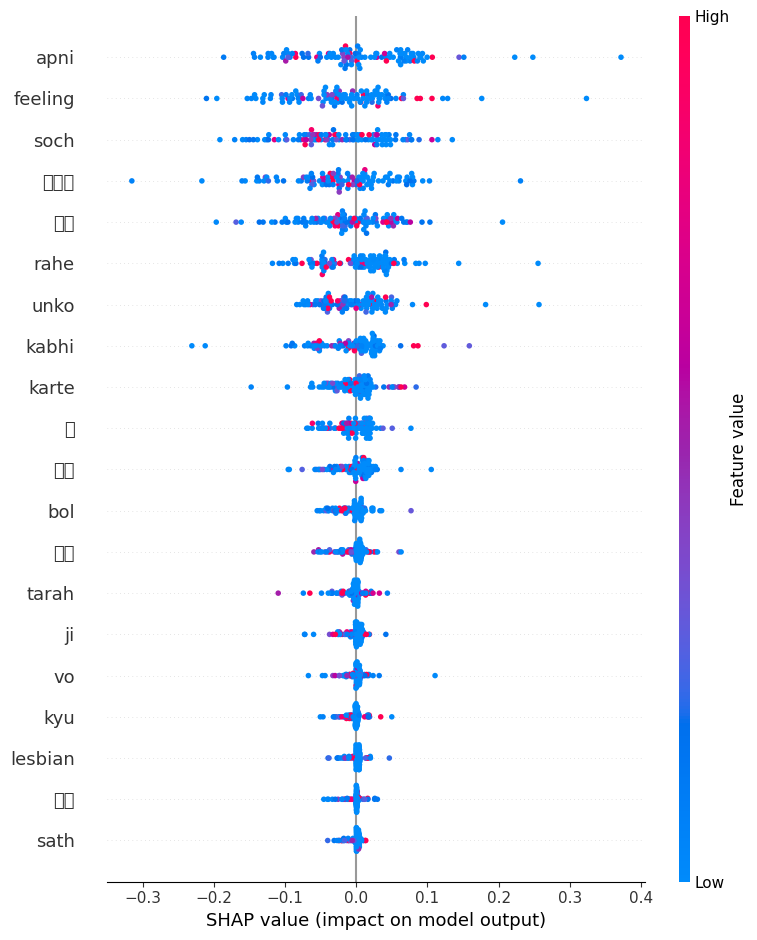

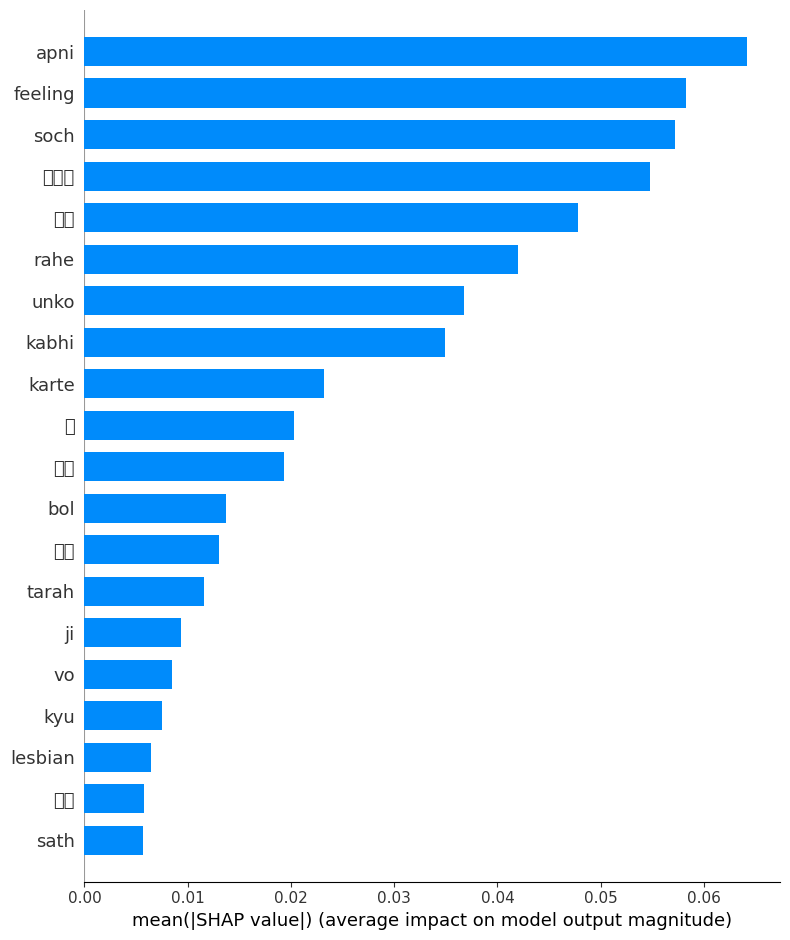

In [ ]:
explainer_dnn, shap_values_dnn = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# DNN + Embeddings

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN+Embedding model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn_emb = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn_emb)
precision = precision_score(y_true_numeric, y_pred_dnn_emb, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn_emb, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn_emb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
10/10 [==============================] - 3s 163ms/step - loss: 0.6875 - accuracy: 0.5839 - val_loss: 0.7582 - val_accuracy: 0.0000e+00
Epoch 2/10
10/10 [==============================] - 1s 126ms/step - loss: 0.6541 - accuracy: 0.6081 - val_loss: 0.7995 - val_accuracy: 0.0000e+00
Epoch 3/10
10/10 [==============================] - 1s 122ms/step - loss: 0.5948 - accuracy: 0.6694 - val_loss: 0.8722 - val_accuracy: 0.3397
Epoch 4/10
10/10 [==============================] - 1s 92ms/step - loss: 0.5613 - accuracy: 0.6823 - val_loss: 0.7094 - val_accuracy: 0.7500
Epoch 5/10
10/10 [==============================] - 1s 93ms/step - loss: 0.4637 - accuracy: 0.7532 - val_loss: 1.1704 - val_accuracy: 0.4295
Epoch 6/10
10/10 [==============================] - 1s 94ms/step - loss: 0.3565 - accuracy: 0.8710 - val_loss: 1.2479 - val_accuracy: 0.4615
Epoch 7/10
10/10 [==============================] - 1s 94ms/step - loss: 0.2115 - accuracy: 0.9516 - val_loss: 1.5362 - val_accuracy: 0.4744
Ep

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn_emb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn_emb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[48  5]
 [18 35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.91      0.81        53
           1       0.88      0.66      0.75        53

    accuracy                           0.78       106
   macro avg       0.80      0.78      0.78       106
weighted avg       0.80      0.78      0.78       106



PermutationExplainer explainer: 107it [09:18,  5.32s/it]


Summary plot as a whole:


Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA})

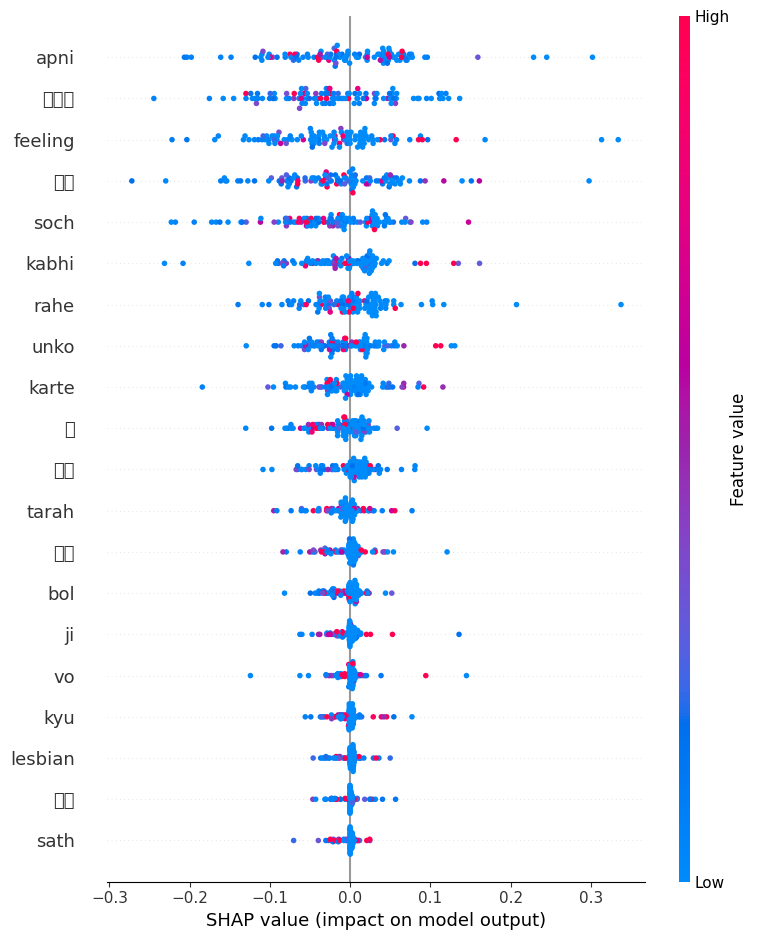

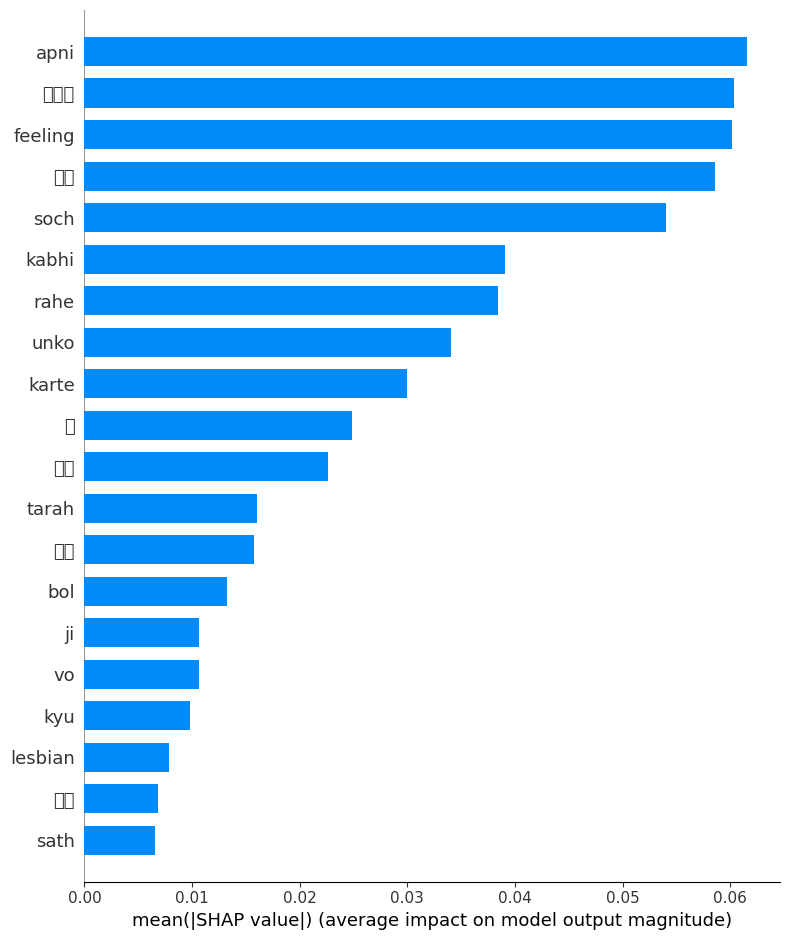

In [ ]:
explainer_dnn_emb, shap_values_dnn_emb = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# Gated Recurrence Unit(GRU)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# # Build GRU model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(GRU(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# # Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=32, validation_split=0.2)

# # Predict on the test set
y_test_predicted_labels = (model.predict(X_test_padded) > 0.5).astype(int)

# # Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels)
precision = precision_score(y_true_numeric, y_test_predicted_labels, average='binary')
recall = recall_score(y_true_numeric, y_test_predicted_labels, average='binary')
f1 = f1_score(y_true_numeric, y_test_predicted_labels, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
20/20 [==============================] - 12s 319ms/step - loss: 0.6834 - accuracy: 0.6016 - val_loss: 0.8066 - val_accuracy: 0.0705
Epoch 2/10
20/20 [==============================] - 5s 259ms/step - loss: 0.5667 - accuracy: 0.7210 - val_loss: 0.7429 - val_accuracy: 0.6859
Epoch 3/10
20/20 [==============================] - 7s 382ms/step - loss: 0.4188 - accuracy: 0.8048 - val_loss: 0.9220 - val_accuracy: 0.5577
Epoch 4/10
20/20 [==============================] - 5s 267ms/step - loss: 0.2148 - accuracy: 0.9177 - val_loss: 1.4429 - val_accuracy: 0.5641
Epoch 5/10
20/20 [==============================] - 7s 381ms/step - loss: 0.0635 - accuracy: 0.9823 - val_loss: 2.1067 - val_accuracy: 0.5128
Epoch 6/10
20/20 [==============================] - 5s 252ms/step - loss: 0.0396 - accuracy: 0.9887 - val_loss: 1.3904 - val_accuracy: 0.6090
Epoch 7/10
20/20 [==============================] - 5s 276ms/step - loss: 0.0239 - accuracy: 0.9919 - val_loss: 3.2813 - val_accuracy: 0.3654
Epoch

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[39 14]
 [23 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.74      0.68        53
           1       0.68      0.57      0.62        53

    accuracy                           0.65       106
   macro avg       0.66      0.65      0.65       106
weighted avg       0.66      0.65      0.65       106



PermutationExplainer explainer: 107it [57:46, 32.70s/it]


Summary plot as a whole:


Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from current font.
Matplotlib currently does not support Devanagari natively.
Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from current font.
Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from current font.
Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from current font.
Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from current font.
Glyph 2360 (\N{DEVANAGARI LETTER SA})

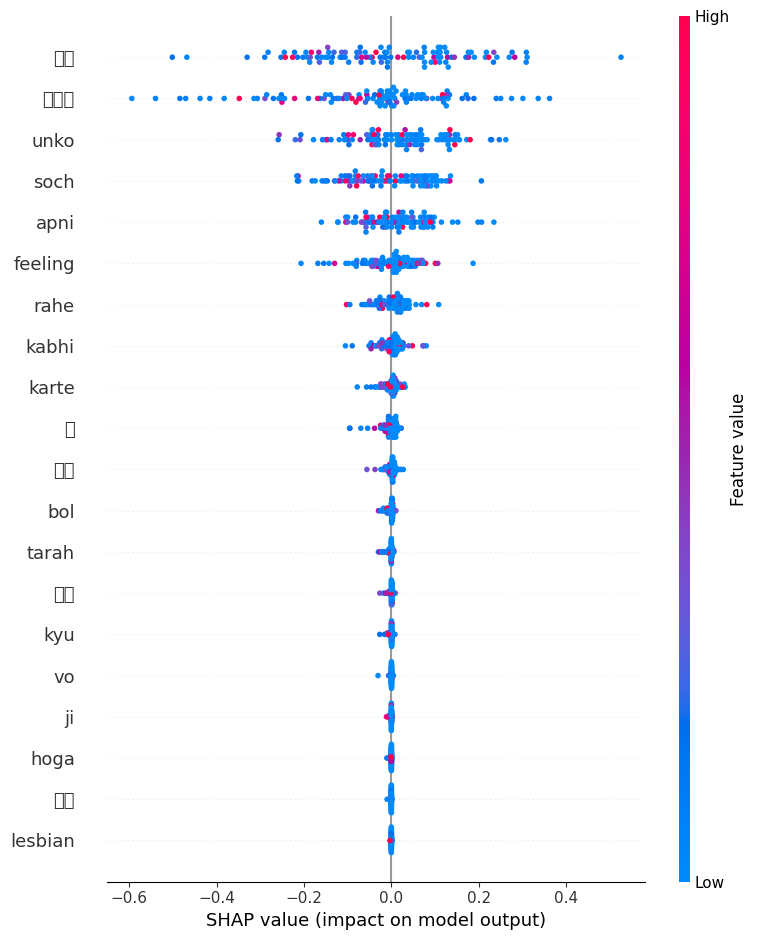

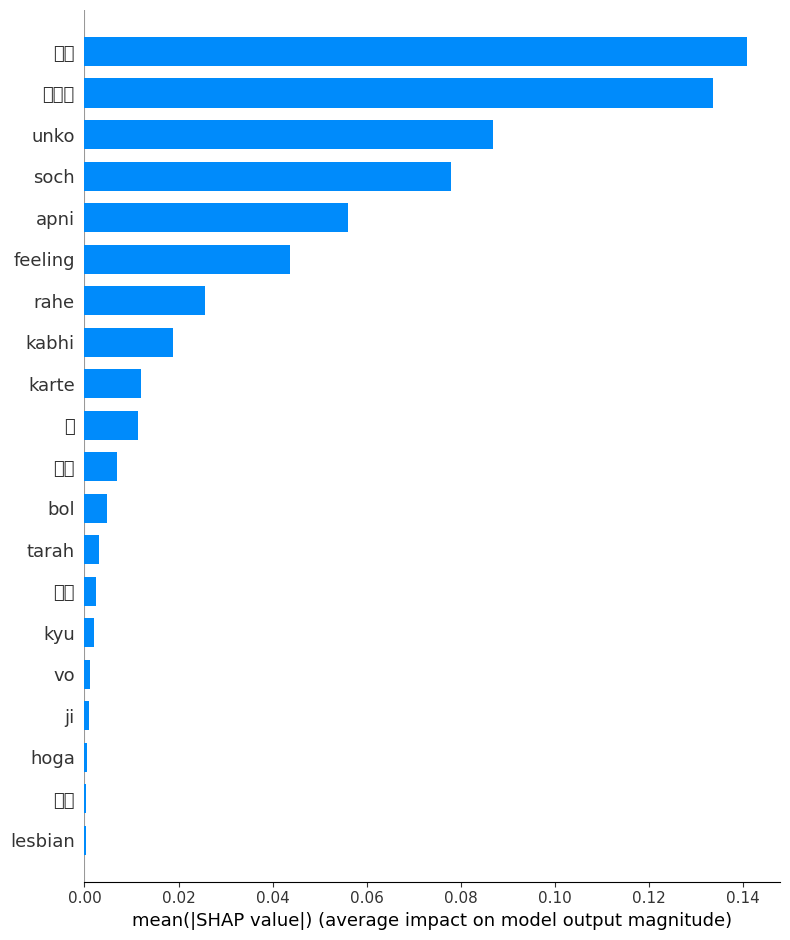

In [ ]:
explainer_dnn_emb, shap_values_dnn_emb = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)